# Run first

In [1]:
import os
import pandas as pd
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec

import pyemu
import flopy

# Prior IES

## Prep (~10min)

In [2]:
run_name = 'local_run26'
o_d = f'../models/{run_name}/{run_name}'
temp_d = f'../models/{run_name}/{run_name}'
m_d_pr = f'../models/{run_name}/pest/master_ies_prior'
m_d = f'../models/{run_name}/pest/master_ies'
output = f'../models/{run_name}/figures'

# phi
f_act = os.path.join(m_d, f"{run_name}.phi.actual.csv")
f_meas = os.path.join(m_d, f"{run_name}.phi.meas.csv")

# open pst file
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))

# observation filenames
pr_oe_fn = os.path.join(m_d, f"{run_name}.0.obs.csv") # prior
pt_oe_fn = os.path.join(m_d, f"{run_name}.3.obs.csv")
noise_fn = os.path.join(m_d, f"{run_name}.obs+noise.csv")
obs_data_fn = os.path.join(m_d, f"{run_name}.obs_data.csv")
# parameters filenames
par_data_fn = os.path.join(m_d, f"{run_name}.par_data.csv")
pr_pe_fn = os.path.join(m_d, f"{run_name}.0.par.csv") # prior
pt_pe_fn = os.path.join(m_d, f"{run_name}.3.par.csv")

# input observation data
obs_data = pd.read_csv(obs_data_fn, index_col=0)
par_data = pd.read_csv(par_data_fn, index_col=0)
headers = obs_data.index.to_list()

# observation ensemble
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=pr_oe_fn)
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=pt_oe_fn)
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=noise_fn)


In [3]:
#parameter ensemble
pr_pe = pd.read_csv(pr_pe_fn, index_col=0)
pt_pe = pd.read_csv(pt_pe_fn, index_col=0)

C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\675159623.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\675159623.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [4]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Prior v Posterior Hist

In [114]:
def group_pdict(pst):
        par = pst.parameter_data
        pdict = {}
        for string in pst.par_groups:
                prefix= string[:3] #set first 3 letters as prefix
                group = pdict.setdefault(prefix, [])
                parnames = par.loc[par.pargp==string, 'parnme'].tolist()
                group.extend(parnames)
        return pdict

In [115]:
pdict = group_pdict(pst)

<Figure size 800x1050 with 0 Axes>

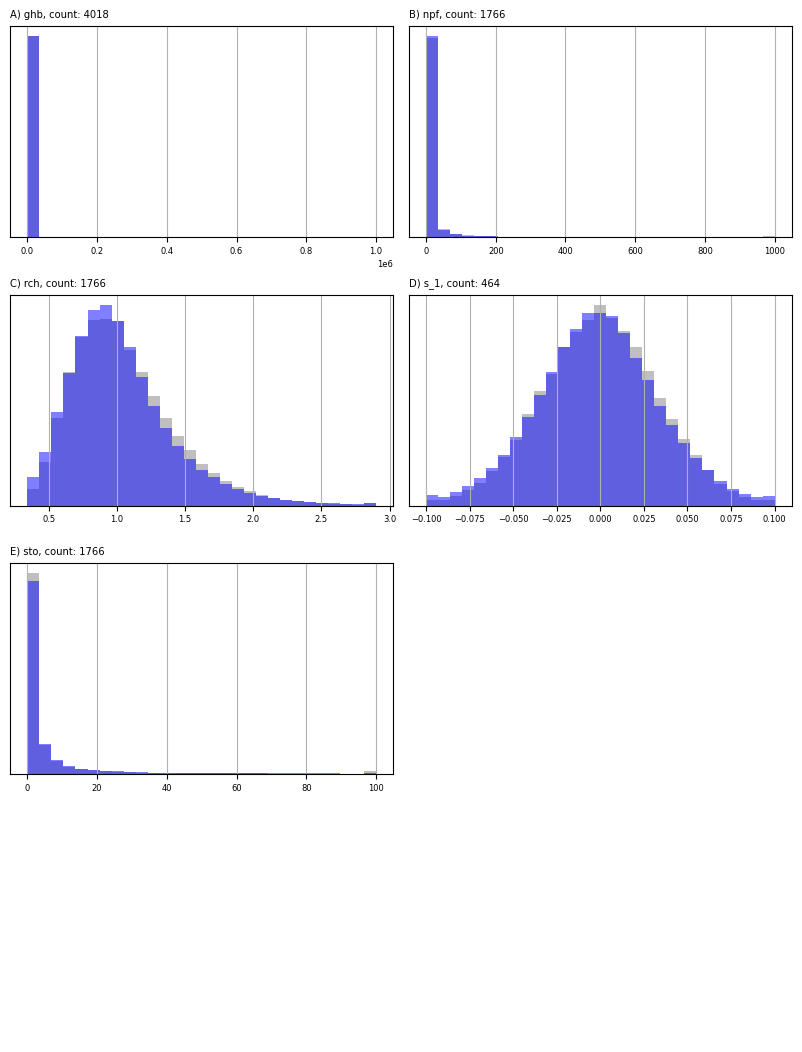

In [124]:
pyemu.plot_utils.ensemble_helper({"0.5":pr_pe,"b":pt_pe}, bins=30, plot_cols=pdict)

In [126]:
pyemu.plot_utils.ensemble_res_1to1({"0.5":pr_oe,"b":pt_oe, "r":noise}, pst=pst)

c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\U

return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\U

return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


...

c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


return type uncaught, losing Ensemble type, returning DataFrame
return type uncaught, losing Ensemble type, returning DataFrame


: 

## Prior

In [2]:
run_name = 'local_run0'
o_d = f'../models/{run_name}/{run_name}'
temp_d = f'../models/{run_name}/{run_name}'
m_d = f'../models/{run_name}/pest/master_ies'

In [81]:
# observations
pr_oe_fn = os.path.join(m_d, f"{run_name}.0.obs.csv")
noise_fn = os.path.join(m_d, f"{run_name}.obs+noise.csv")

In [ ]:
# Read only the headers
headers = pd.read_csv(pr_oe_fn, nrows=0).columns.tolist()

In [4]:
# observations
pr_pe_fn = os.path.join(m_d, f"{run_name}.0.par.csv")
# Read only the headers
params_headers = pd.read_csv(pr_pe_fn, nrows=0).columns.tolist()

## Diagnostics

## 1:1

<Figure size 800x1050 with 0 Axes>

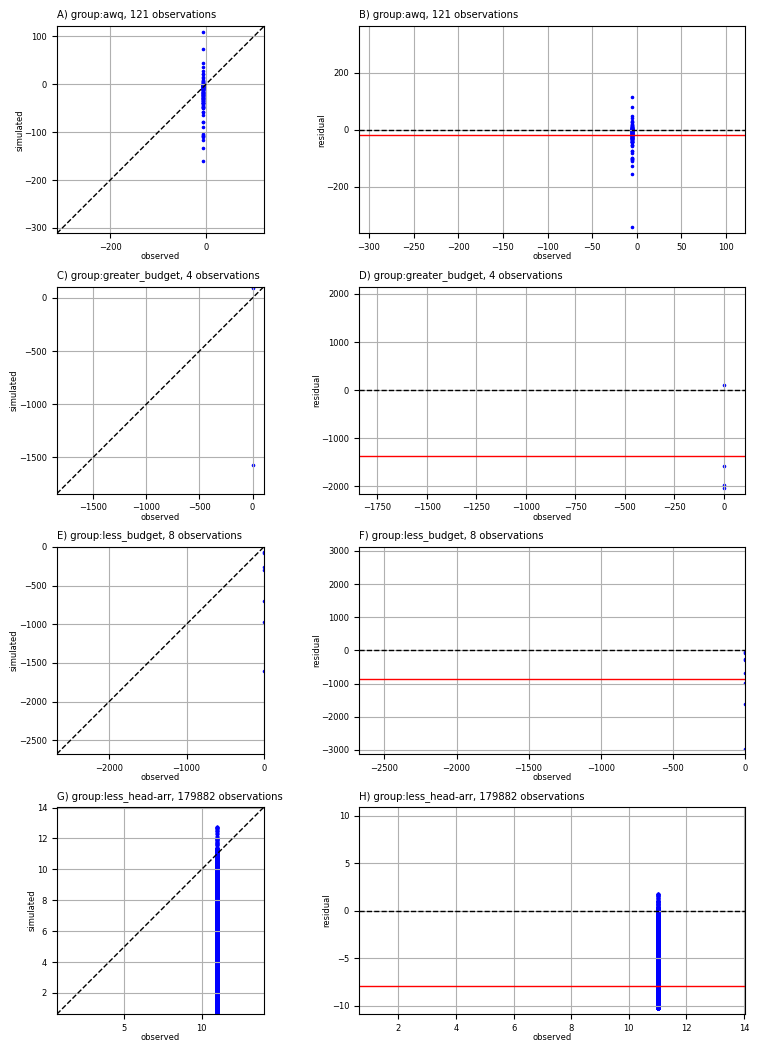

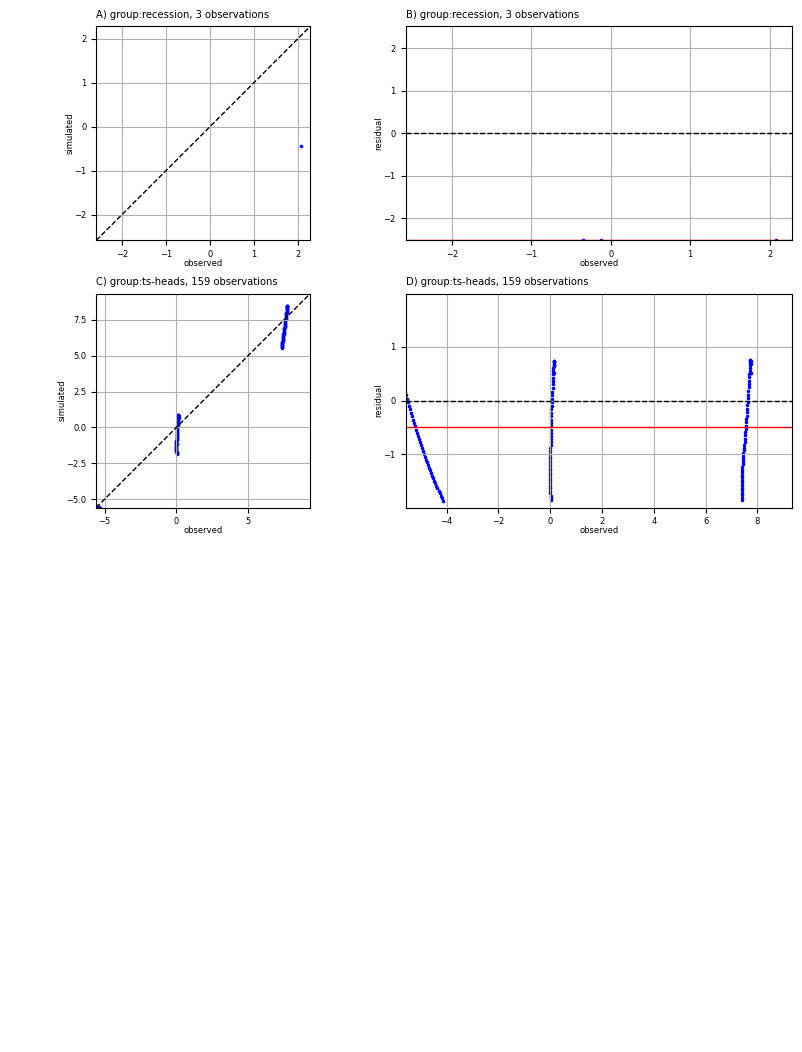

In [3]:
pst.plot('1to1')
plt.show()

## Phi prior & posterior

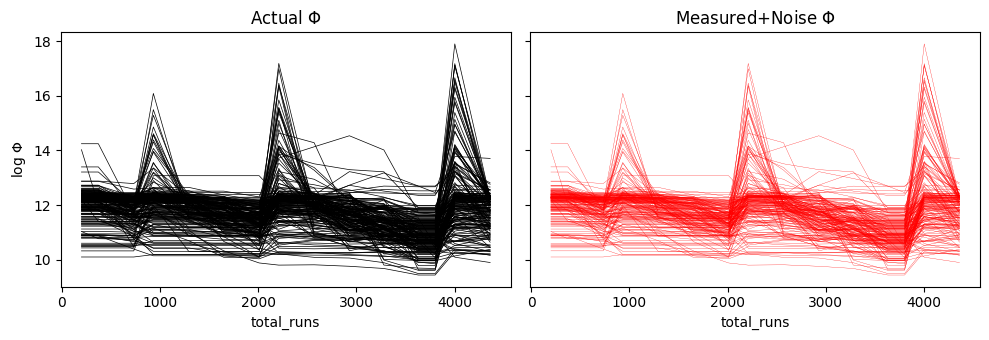

In [4]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
ax = axes[0]
phi = pd.read_csv(f_act, index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual $\Phi$')
ax.set_ylabel(r'log $\Phi$')
# right
ax = axes[-1]
phi = pd.read_csv(f_meas,index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise $\Phi$')
fig.tight_layout()

# save
fig_fn = os.path.join(output, 'output.phi_comparison.png')
plt.savefig(fig_fn, dpi=300)

plt.show()

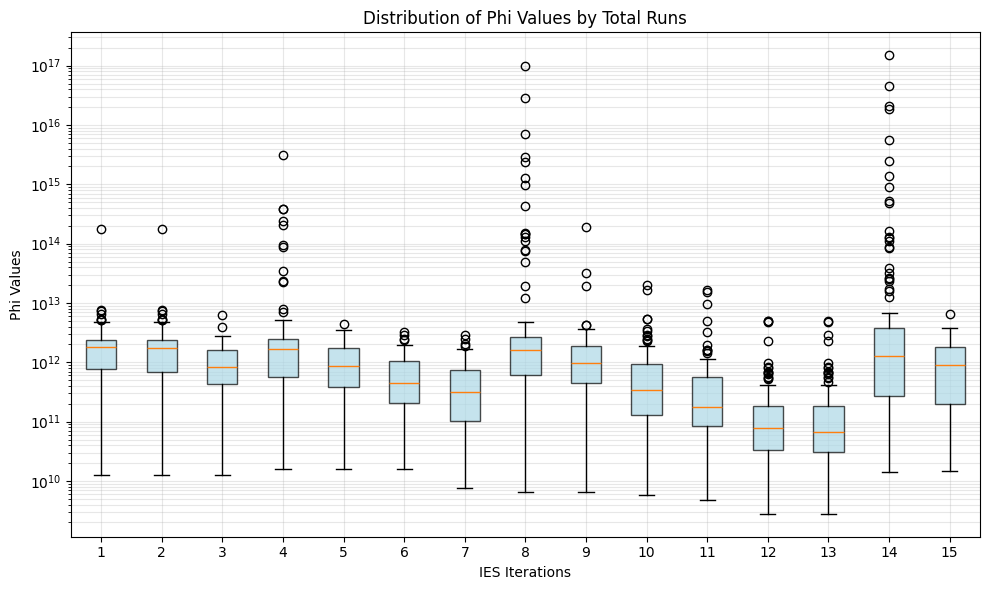

In [7]:
# Read data (assuming phi_act is your dataframe)
phi_act = pd.read_csv(f_act, index_col=0)

# Prepare data for boxplot
box_data = []
x_labels = []

# Get the columns we want (0-99 + base)
value_columns = [str(i) for i in range(100)] + ['base']

for total_runs in phi_act.index:
    # Get values for this row across columns 0-99 + base
    row_values = []
    for col in value_columns:
        if col in phi_act.columns:
            row_values.append(phi_act.loc[total_runs, col])
    
    box_data.append(row_values)

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(box_data, patch_artist=True)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0, 1, len(box_data)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_xlabel('IES Iterations')
ax.set_ylabel('Phi Values')
ax.set_title('Distribution of Phi Values by Total Runs')
ax.set_yscale('log')  # Use log scale since phi values vary greatly
ax.grid(which='both', alpha=0.3)

# Set custom x-axis labels
# ax.set_xticklabels(['0', '1', '2', '3'])

plt.tight_layout()

# save
fig_fn = os.path.join(output, 'output.phi_by_total_runs_boxplot.png')
plt.savefig(fig_fn, dpi=300, bbox_inches='tight')

plt.show()

## Prior data conflict check

In [ ]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:budget')]

# heads
pre_oe_budget = pd.read_csv(pr_oe_fn, usecols=desired_cols)
noise = pd.read_csv(os.path.join(m_d,f"{run_name}.obs+noise.csv"), index_col=0)

: 

: 

In [80]:
params_headers

['real_name',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:27_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:32_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:37_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:42_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:47_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:17_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:22_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:27_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:32_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:37_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:42_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:47_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:52_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:12_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:17_zone:1',
 'pname:n

## Heads (array)

### Prep

In [6]:
extract_kper =  lambda x: int(x.split('_')[0].split('-')[2].replace('kper', ''))
extract_kstp = lambda x: int(x.split('_')[0].split('-')[3].replace('kstp', ''))
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

In [7]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:h-')]

# heads
pre_oe_modelheads = pd.read_csv(pr_oe_fn, usecols=desired_cols)
pt_oe_modelheads = pd.read_csv(pt_oe_fn, usecols=desired_cols)

In [8]:
def to_modelhead_df(pre_oe_modelheads):
    input_df = pre_oe_modelheads.transpose()
    input_df['kper'] = input_df.index.map(extract_kper)
    input_df['kstp'] = input_df.index.map(extract_kstp)
    input_df['i'] = input_df.index.map(extract_i)
    input_df['j'] = input_df.index.map(extract_j)
    return input_df

In [9]:
input_df = to_modelhead_df(pre_oe_modelheads)
input_pt_df = to_modelhead_df(pt_oe_modelheads)

In [10]:
nkper = input_df['kper'].unique()
nstp = input_df['kstp'].unique()

In [11]:
# get all the heads into an array which we can now call to plot
arrs = {}
for i in set(zip(input_df['kper'], input_df['kstp'])):
    kper, kstp = i
    idf = input_df[(input_df['kper'] == kper) & (input_df['kstp'] == kstp)]
    i_arrs = []
    for real in idf.columns[:-4]:
        arr = idf.pivot(index='i', columns='j', values=real).to_numpy()
        max_nan = 1e+30
        arr = np.where(arr == max_nan, np.nan, arr)
        i_arrs.append(arr)
    i_stack = np.stack(i_arrs)
    arrs[i] = {
        'i_stack': i_stack,
        'mean': np.mean(i_stack, axis=0),
        'min': np.min(i_stack, axis=0),
        'max': np.max(i_stack, axis=0),
        'std': np.std(i_stack, axis=0),
    }

In [12]:
## SUBSET heads

# get all the heads into an array which we can now call to plot
arrs = {}
for i in set(zip(input_df['kper'], input_df['kstp'])):
    kper, kstp = i
    idf = input_df[(input_df['kper'] == kper) & (input_df['kstp'] == kstp)]
    i_arrs = []
    for real in [188]: #[102,106,188]
        arr = idf.pivot(index='i', columns='j', values=real).to_numpy()
        max_nan = 1e+30
        arr = np.where(arr == max_nan, np.nan, arr)
        i_arrs.append(arr)
    i_stack = np.stack(i_arrs)
    arrs[i] = {
        'i_stack': i_stack,
        'mean': np.mean(i_stack, axis=0),
        'min': np.min(i_stack, axis=0),
        'max': np.max(i_stack, axis=0),
        'std': np.std(i_stack, axis=0),
    }

In [13]:
list(pt_reals_list)

NameError: name 'pt_reals_list' is not defined

### Stess period stats

In [98]:
len(arrs[(kper, 1)]['i_stack'])

3

In [1]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))

# Calculate vmin/vmax for each row (stat type) across all kpers
mean_arrays = [arrs[(kper, 1)]['mean'] for kper in range(1, 5)]
min_arrays = [arrs[(kper, 1)]['min'] for kper in range(1, 5)]
max_arrays = [arrs[(kper, 1)]['max'] for kper in range(1, 5)]
std_arrays = [arrs[(kper, 1)]['std'] for kper in range(1, 5)]

# Calculate shared vmin/vmax for each row
mean_vmin, mean_vmax = np.nanmin(mean_arrays), np.nanmax(mean_arrays)
min_vmin, min_vmax = np.nanmin(min_arrays), np.nanmax(min_arrays)
max_vmin, max_vmax = np.nanmin(max_arrays), np.nanmax(max_arrays)
std_vmin, std_vmax = np.nanmin(std_arrays), np.nanmax(std_arrays)

for idx, kper in enumerate(range(1, 5)):
    key = (kper, 1)
    mean_arr = arrs[key]['mean']
    std_arr = arrs[key]['std']
    min_arr = arrs[key]['min']
    max_arr = arrs[key]['max']
    
    # Row 0: Mean
    im0 = axes[0, idx].imshow(mean_arr, cmap='viridis', vmin=mean_vmin, vmax=mean_vmax)
    
    # Row 1: Min
    im1 = axes[1, idx].imshow(min_arr, cmap='magma', vmin=min_vmin, vmax=min_vmax)

    # Row 2: Max
    im2 = axes[2, idx].imshow(max_arr, cmap='magma', vmin=max_vmin, vmax=max_vmax)

    # Row 3: Std
    im3 = axes[3, idx].imshow(std_arr, cmap='magma', vmin=std_vmin, vmax=std_vmax)

    if idx == 0:
        axes[0, idx].set_title(f'kper={kper}, kstp=1 mean')
        axes[1, idx].set_title(f'min')
        axes[2, idx].set_title(f'max')
        axes[3, idx].set_title(f'std')
        plt.colorbar(im0, ax=axes[0, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im1, ax=axes[1, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im2, ax=axes[2, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im3, ax=axes[3, idx], fraction=0.046, pad=0.04)


for ax in axes.flat:
    ax.set_xlabel('j')
    ax.set_ylabel('i')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Timesteps within stress period

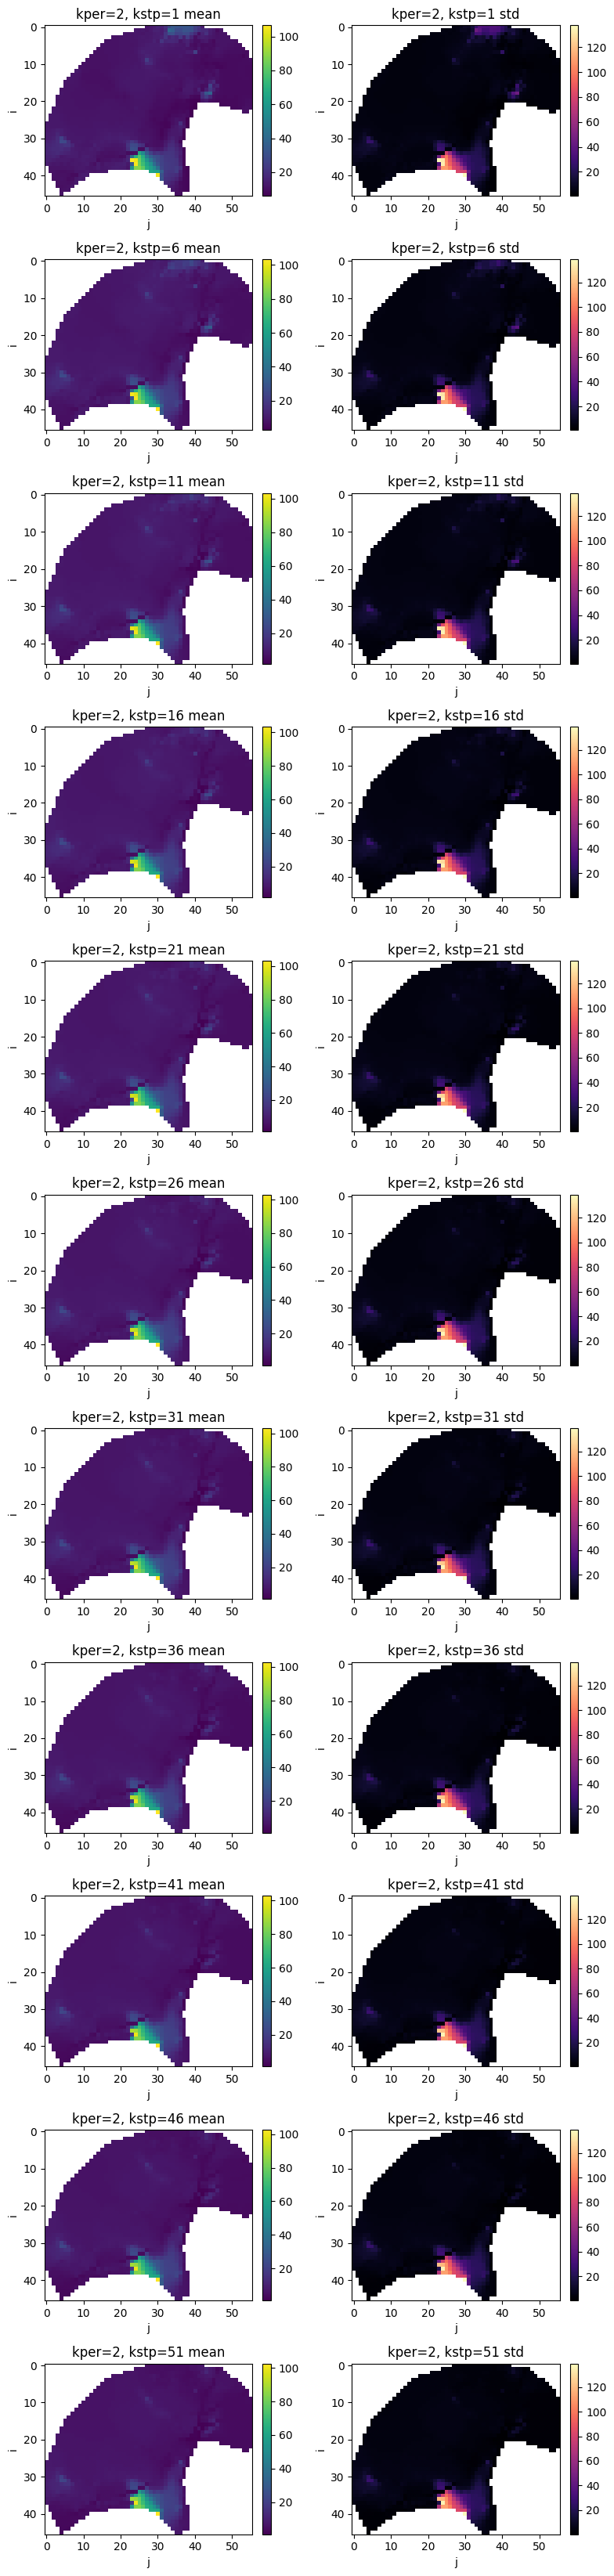

In [78]:
kper = 2
kstp_steps = range(1, nstp.max(), 5)  # every 5th kstp

fig, axes = plt.subplots(nrows=len(kstp_steps), ncols=2, figsize=(8, 3 * len(kstp_steps)))

for idx, kstp in enumerate(kstp_steps):
    key = (kper, kstp)
    mean_arr = arrs[key]['mean']
    std_arr = arrs[key]['std']

    im0 = axes[idx, 0].imshow(mean_arr, cmap='viridis')
    axes[idx, 0].set_title(f'kper={kper}, kstp={kstp} mean')
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04)

    im1 = axes[idx, 1].imshow(std_arr, cmap='magma')
    axes[idx, 1].set_title(f'kper={kper}, kstp={kstp} std')
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('j')
        ax.set_ylabel('i')

plt.tight_layout()
plt.show()

### individual plot

In [84]:
list(pt_reals_list)

[68, 69, 102, 103, 76, 172, 178, 188, 125]

In [63]:
arrs[key]['i_stack'][0]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(46, 56))

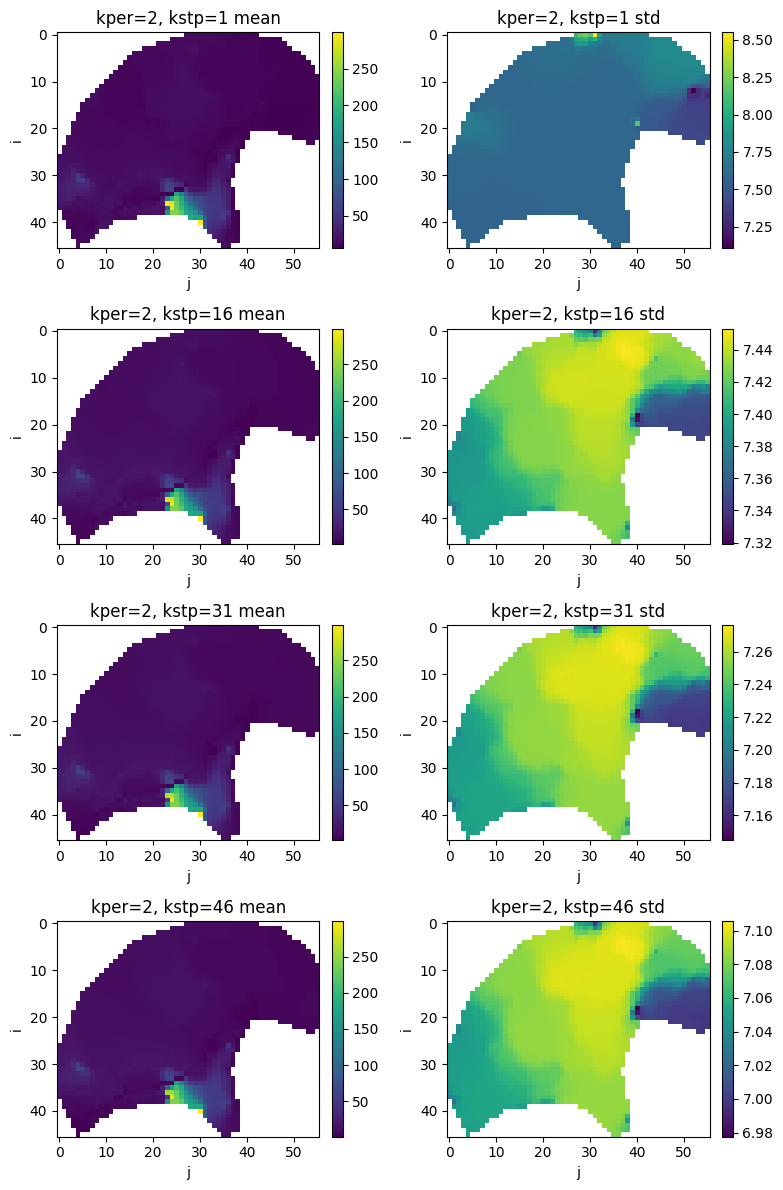

In [92]:
kper = 2
kstp_steps = range(1, nstp.max(), 15)  # every 5th kstp

fig, axes = plt.subplots(nrows=len(kstp_steps), ncols=2, figsize=(8, 3 * len(kstp_steps)))

for idx, kstp in enumerate(kstp_steps):
    key = (kper, kstp)
    mean_arr = arrs[key]['i_stack'][7]
    std_arr = arrs[key]['i_stack'][8]

    im0 = axes[idx, 0].imshow(mean_arr, cmap='viridis')
    axes[idx, 0].set_title(f'kper={kper}, kstp={kstp} mean')
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04)

    im1 = axes[idx, 1].imshow(std_arr, cmap='viridis')
    axes[idx, 1].set_title(f'kper={kper}, kstp={kstp} std')
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('j')
        ax.set_ylabel('i')

plt.tight_layout()
plt.show()

### Timesteps within stress period (Animated)

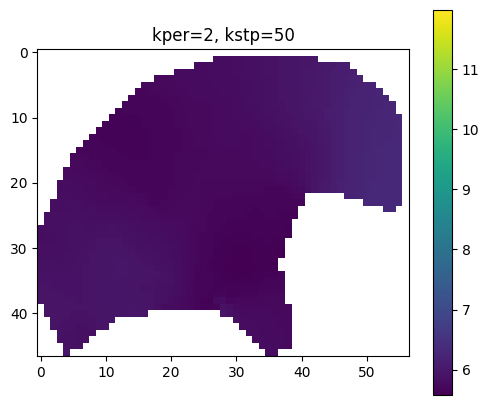

In [ ]:
kper = 2

fig, ax = plt.subplots(figsize=(6, 5))
vmin = min(np.nanmin(arrs[(kper, i)]['mean']) for i in range(1, nstp.max()))
vmax = max(np.nanmax(arrs[(kper, i)]['mean']) for i in range(1, nstp.max()))
im = ax.imshow(arrs[(kper, 1)]['mean'], cmap='viridis', vmin=vmin, vmax=vmax)
cb = plt.colorbar(im, ax=ax)
ax.set_title(f'kper={kper}, kstp=1')

def update(frame):
    arr = arrs[(kper, frame)]['mean']
    im.set_data(arr)
    ax.set_title(f'kper={kper}, kstp={frame}')
    return [im]

ani = animation.FuncAnimation(
    fig, update, frames=range(1, nstp.max()), interval=200, blit=True
)

ani.save(f'{kper}_animation.gif', writer='pillow', fps=5)

## Budget

### Prep

In [ ]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

In [ ]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:budget')]

# data
pre_oe_budget = pd.read_csv(pr_oe_fn, usecols=desired_cols)
budget_noise = pd.read_csv(noise_fn, usecols=desired_cols)

### Diagnostics

In [ ]:
budget_noise.head()

,oname:budget_otype:lst_usecol:awanui_kper:1,oname:budget_otype:lst_usecol:awanui_kper:2,oname:budget_otype:lst_usecol:awanui_kper:3,oname:budget_otype:lst_usecol:awanui_kper:4,oname:budget_otype:lst_usecol:confined_kper:1,oname:budget_otype:lst_usecol:confined_kper:2,oname:budget_otype:lst_usecol:confined_kper:3,oname:budget_otype:lst_usecol:confined_kper:4,oname:budget_otype:lst_usecol:inout_kper:1,oname:budget_otype:lst_usecol:inout_kper:2,...,oname:budget_otype:lst_usecol:spring_kper:3,oname:budget_otype:lst_usecol:spring_kper:4,oname:budget_otype:lst_usecol:stoss_kper:1,oname:budget_otype:lst_usecol:stoss_kper:2,oname:budget_otype:lst_usecol:stoss_kper:3,oname:budget_otype:lst_usecol:stoss_kper:4,oname:budget_otype:lst_usecol:total_kper:1,oname:budget_otype:lst_usecol:total_kper:2,oname:budget_otype:lst_usecol:total_kper:3,oname:budget_otype:lst_usecol:total_kper:4
0,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
1,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
2,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
3,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
4,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297


Text(0.5, 1.0, 'oname:budget_otype:lst_usecol:awanui_kper:1')

Text(0.5, 1.0, 'oname:budget_otype:lst_usecol:awanui_kper:1')

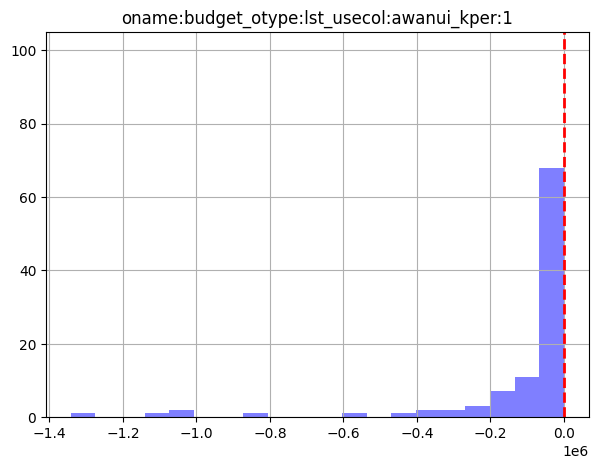

In [ ]:
kper = 1
col = 'awanui'
col = f'oname:budget_otype:lst_usecol:{col}_kper:{kper}'
bins=20
fig, ax = plt.subplots(1,1,figsize=(7,5))

# plot posterior/noise (red)
budget_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
pre_oe_budget.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pre_oe_budget.loc[:,col].mean()
# ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = budget_noise.loc[:,col].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

### Boxplots

In [ ]:
def format_bgtdf(df):
    tdf = df.transpose()
    tdf['kper'] = tdf.index.map(extract_kper)
    tdf['usecol'] = tdf.index.map(extract_usecol)
    return tdf

budget_df = format_bgtdf(pre_oe_budget)

In [ ]:
budget_df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,kper,usecol
oname:budget_otype:lst_usecol:awanui_kper:1,-1024300.0,-18094.70,-55164.9000,-1333.3100,-19089.50,-44172.0,-121400.0,-14237.9000,-0.588700,-1425.690,...,-47455.90,-26052.30,-1341730.0,-57057.70,-1.137400e+06,-4418.370,-20345.40,-731.623,1,awanui
oname:budget_otype:lst_usecol:awanui_kper:2,-11780.8,-34114.10,-160.3030,-0.1028,-40842.60,-22302.0,-73277.4,-5.1414,-0.046148,-545.091,...,-3197.29,-12172.10,-898789.0,-2247.31,-1.130130e+02,-918.162,-5773.02,-969.417,2,awanui
oname:budget_otype:lst_usecol:awanui_kper:3,-275680.0,-6290.53,-5523.4800,-890.4310,-3613.04,-41410.3,-112118.0,-495.2520,-0.156000,-802.281,...,-15749.90,-4165.64,-1818330.0,-32344.60,-4.031400e+04,-3335.460,-3675.52,-167.372,3,awanui
oname:budget_otype:lst_usecol:awanui_kper:4,-10826.2,-15510.20,-14.4612,-0.1521,-8891.13,-23641.6,-72948.9,-1.0438,-0.024713,-592.636,...,-1667.03,-2535.66,-1328980.0,-2551.77,-5.944600e+00,-942.087,-1399.91,-302.193,4,awanui
oname:budget_otype:lst_usecol:confined_kper:1,1008250.0,2175.08,105867.0000,17138.9000,20466.20,18892.3,30198.7,36701.5000,6275.600000,1957.020,...,41273.20,-53264.70,193534.0,56108.20,1.467230e+06,3242.520,16317.20,-471.286,1,confined


In [ ]:
budget_df.melt(
    id_vars=['usecol', 'kper'],
    )

,usecol,kper,variable,value
0,awanui,1,0,-1.024300e+06
1,awanui,2,0,-1.178080e+04
2,awanui,3,0,-2.756800e+05
3,awanui,4,0,-1.082620e+04
4,confined,1,0,1.008250e+06
...,...,...,...,...
3595,stoss,4,99,1.243600e+04
3596,total,1,99,-6.495360e-01
3597,total,2,99,2.197270e-01
3598,total,3,99,2.951290e+00


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.


<Axes: xlabel='usecol', ylabel='value'>

c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.


<Axes: xlabel='usecol', ylabel='value'>

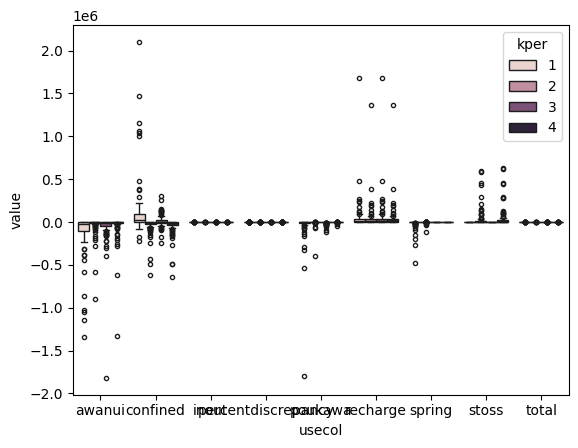

In [ ]:
import seaborn as sns

bx_df = budget_df.melt(
    id_vars=['usecol', 'kper'],
    )

sns.boxplot(
    data = bx_df,
    x='usecol',
    y='value',
    hue='kper',
    fliersize=3
    # log_scale=True
)

In [ ]:
budget_df.melt()

,variable,value
0,0,-1024300.0
1,0,-11780.8
2,0,-275680.0
3,0,-10826.2
4,0,1008250.0
...,...,...
3667,usecol,stoss
3668,usecol,total
3669,usecol,total
3670,usecol,total


C:\Users\tfo46\AppData\Local\Temp\ipykernel_600\2892174719.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


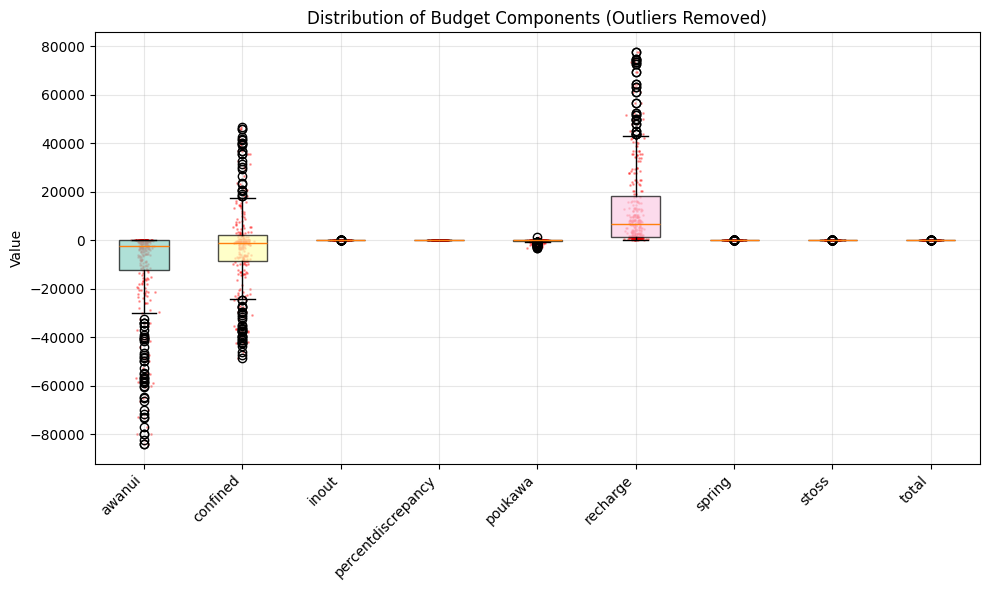

Outlier removal summary:
awanui: 59 outliers removed (14.8%)
confined: 104 outliers removed (26.0%)
inout: 69 outliers removed (17.2%)
percentdiscrepancy: 158 outliers removed (39.5%)
poukawa: 78 outliers removed (19.5%)
recharge: 40 outliers removed (10.0%)
spring: 87 outliers removed (21.8%)
stoss: 97 outliers removed (24.2%)
total: 69 outliers removed (17.2%)


In [ ]:
# Create a single boxplot with all usecols on the same plot (outliers removed)
unique_usecols = budget_df['usecol'].unique()

# Prepare data for boxplot - separate list for each usecol with outlier removal
boxplot_data = []
labels = []

def remove_outliers(data, method='iqr'):
    """Remove outliers using IQR method"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data[(data >= lower_bound) & (data <= upper_bound)]

for usecol in unique_usecols:
    df_sub = budget_df[budget_df['usecol'] == usecol]
    value_cols = [col for col in df_sub.columns if col not in ['kper', 'usecol']]
    
    # Combine all values for this usecol
    all_values = []
    for col in value_cols:
        values = df_sub[col].dropna().values
        all_values.extend(values)
    
    # Remove outliers
    all_values = np.array(all_values)
    filtered_values = remove_outliers(all_values)
    
    boxplot_data.append(filtered_values)
    labels.append(usecol)

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_usecols)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points with jitter for each category
np.random.seed(42)  # For reproducible jitter
for i, values in enumerate(boxplot_data):
    x_pos = np.random.normal(i+1, 0.04, size=len(values))  # Add jitter around position i+1
    ax.scatter(x_pos, values, alpha=0.3, s=1, color='red')

ax.set_ylabel('Value')
ax.set_title('Distribution of Budget Components (Outliers Removed)')
ax.grid(True, alpha=0.3)

# Rotate x-axis labels if they're long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary of outlier removal
print("Outlier removal summary:")
for i, usecol in enumerate(unique_usecols):
    original_count = len(np.concatenate([df_sub[col].dropna().values 
                                       for col in df_sub.columns 
                                       if col not in ['kper', 'usecol']
                                       for df_sub in [budget_df[budget_df['usecol'] == usecol]]]))
    filtered_count = len(boxplot_data[i])
    removed_count = original_count - filtered_count
    print(f"{usecol}: {removed_count} outliers removed ({removed_count/original_count*100:.1f}%)")

## Timeseries (heads)

### Prep

In [5]:
heads_truth = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\truth\output.sample_heads.truth.csv"
truth_df = pd.read_csv(heads_truth, index_col=0)

In [6]:
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:ts-heads')]

# data
pre_oe_ts = pd.read_csv(pr_oe_fn, usecols=desired_cols)
pt_oe_ts = pd.read_csv(pt_oe_fn, usecols=desired_cols)
ts_noise = pd.read_csv(noise_fn, usecols=desired_cols)

### Diagnostics

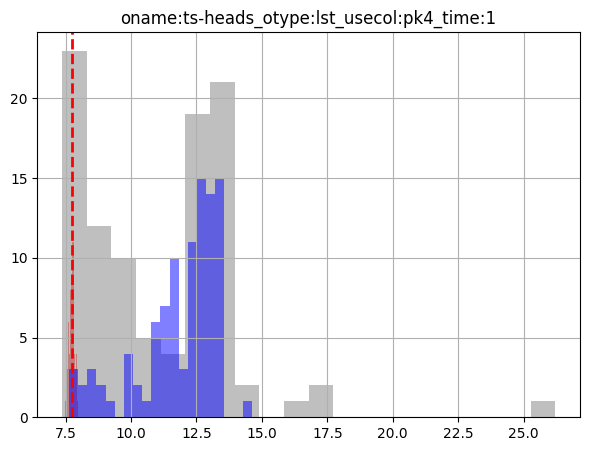

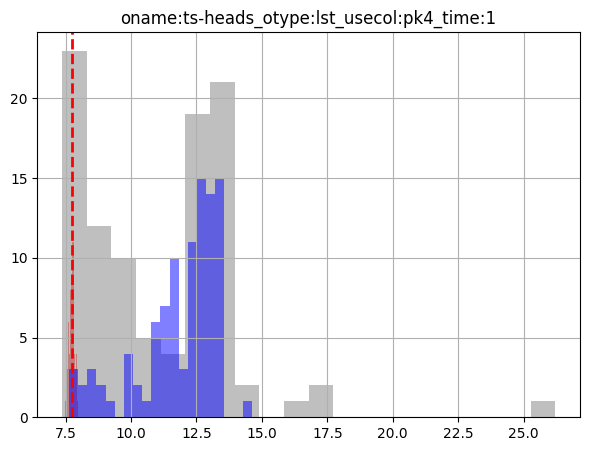

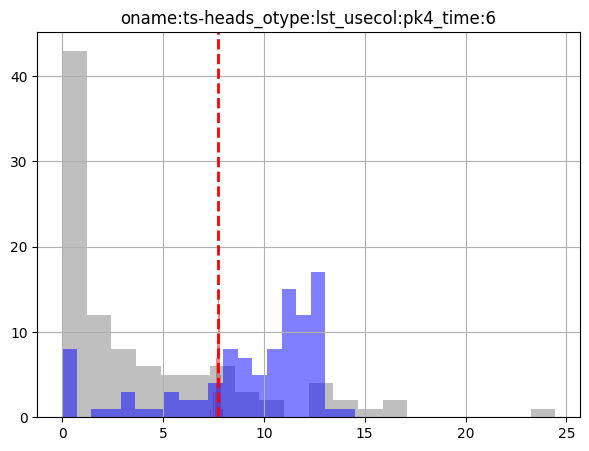

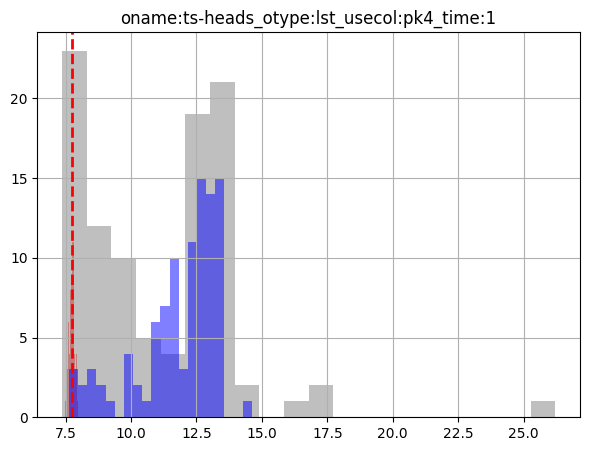

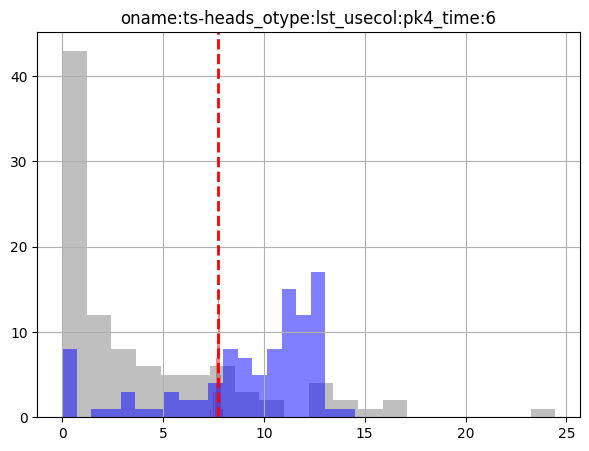

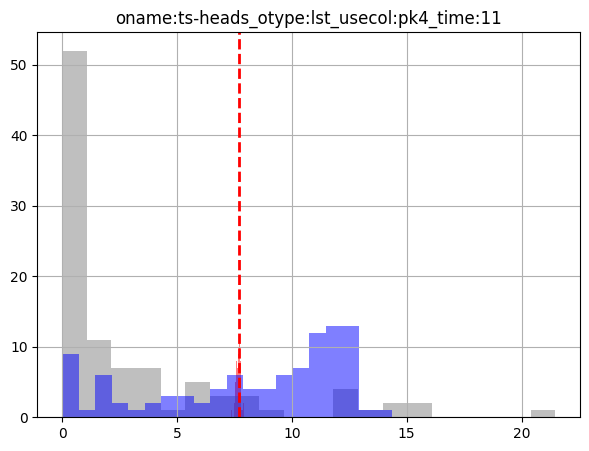

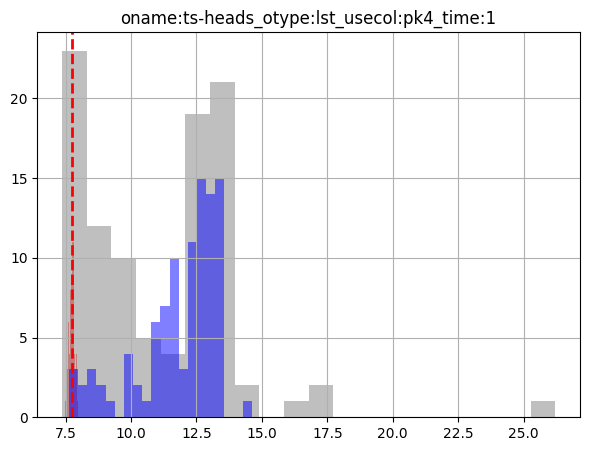

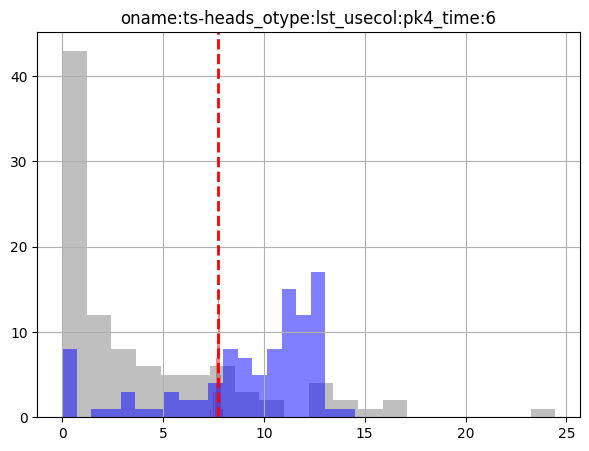

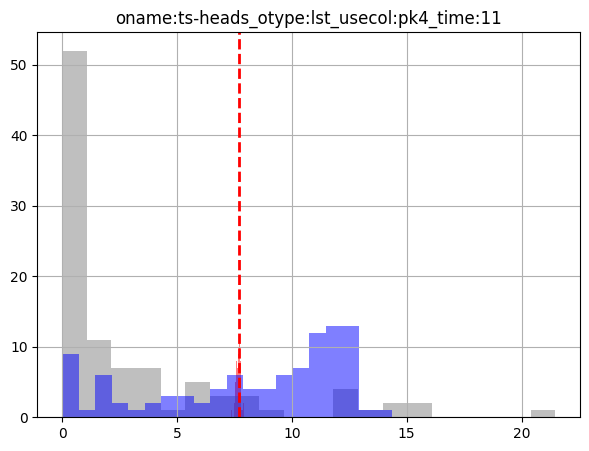

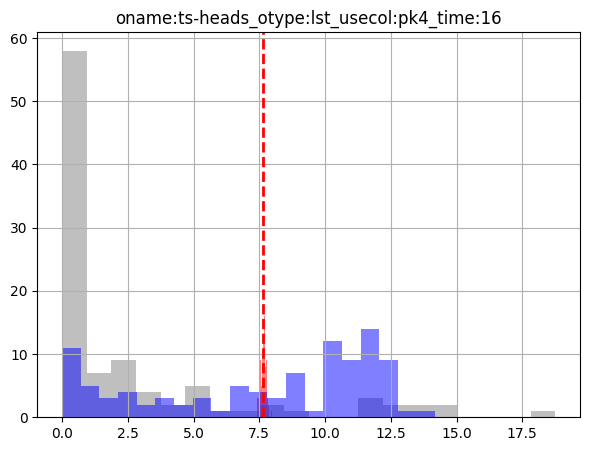

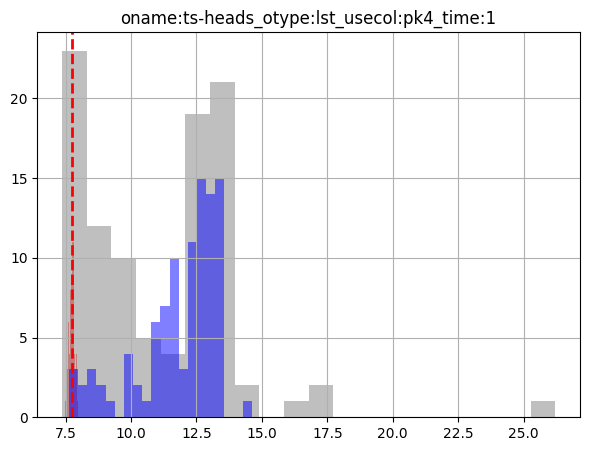

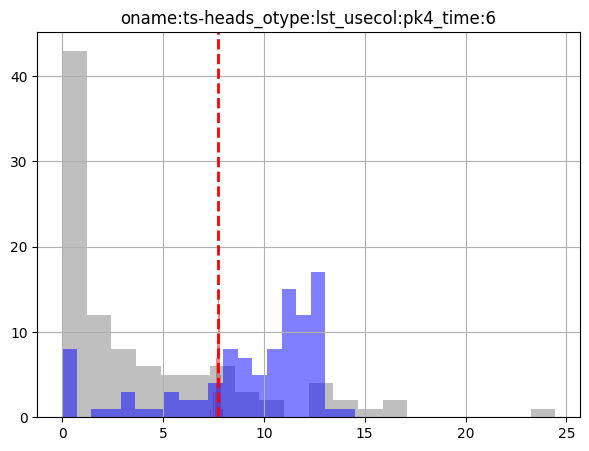

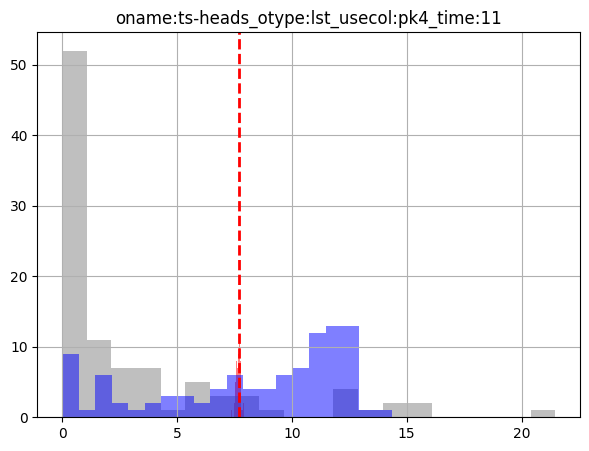

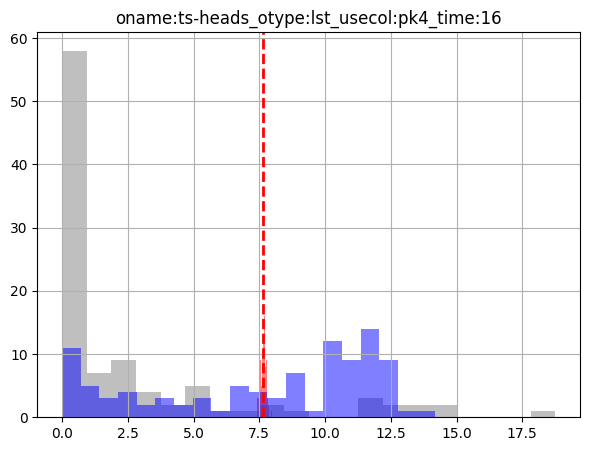

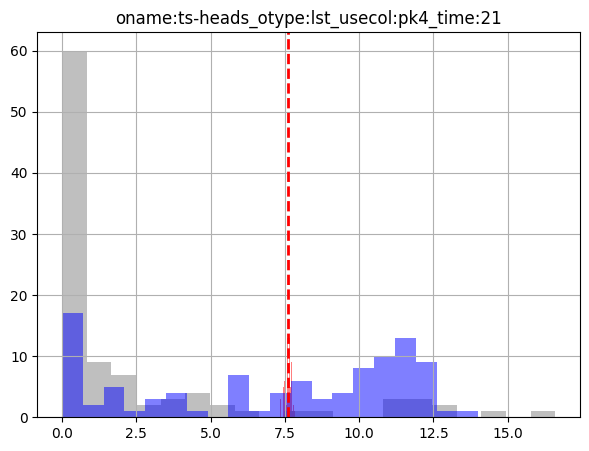

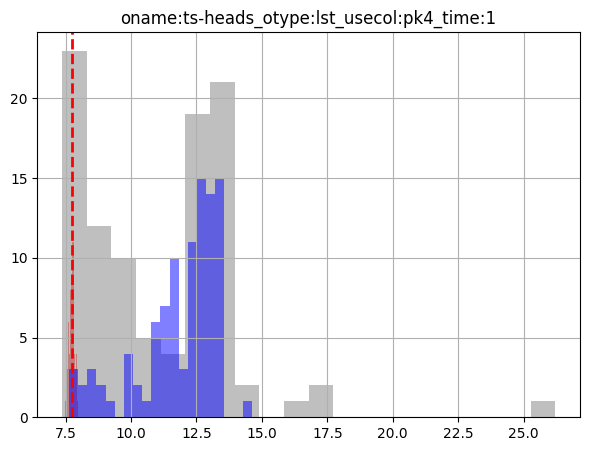

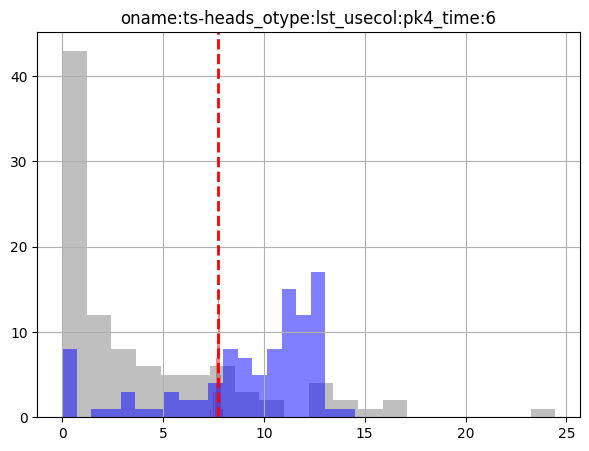

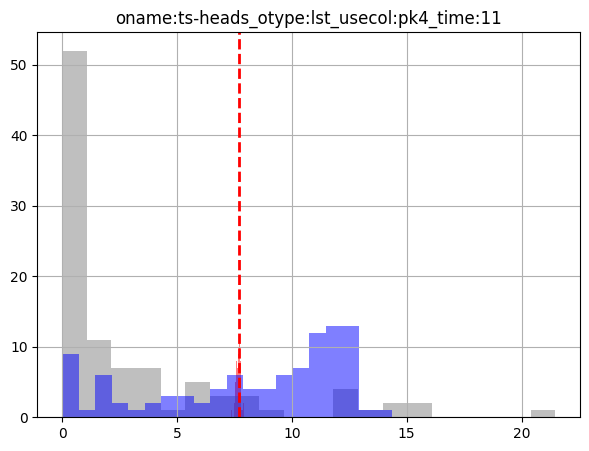

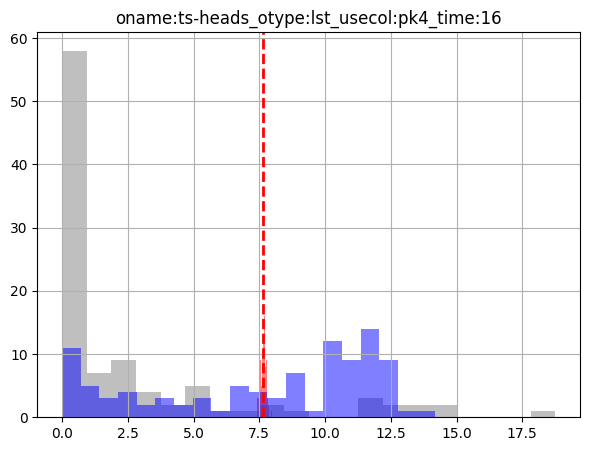

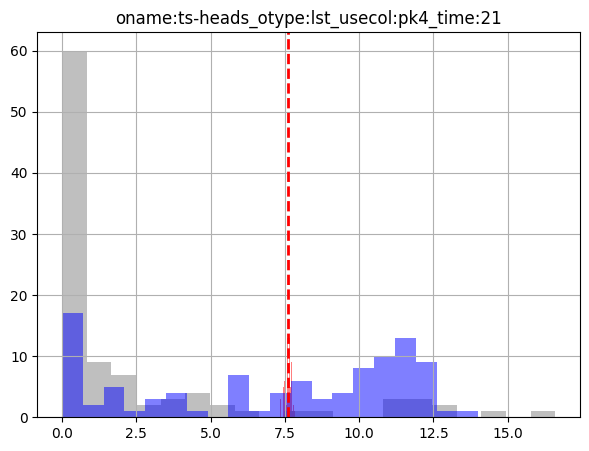

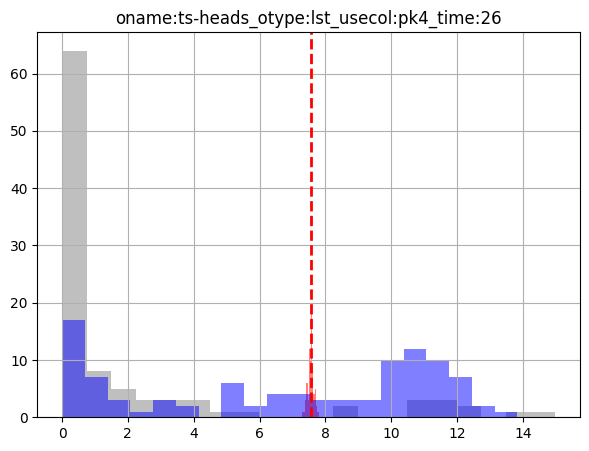

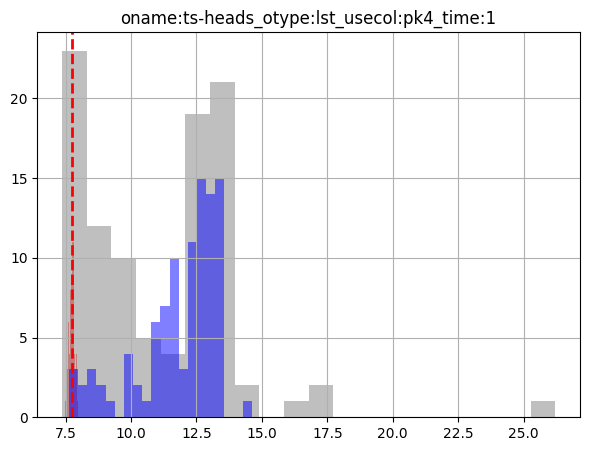

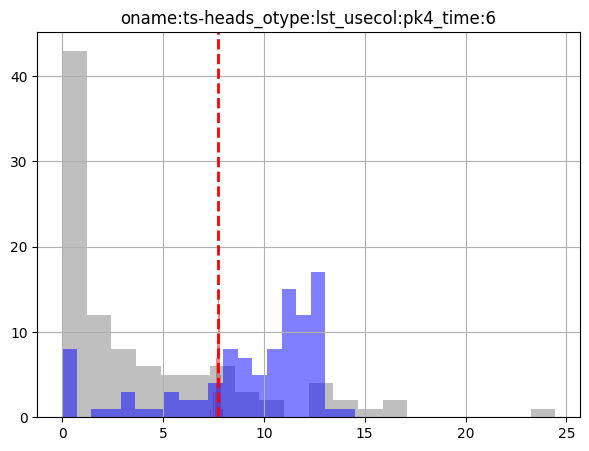

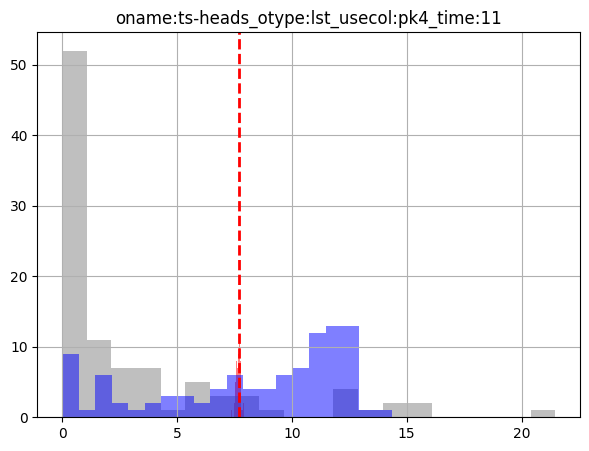

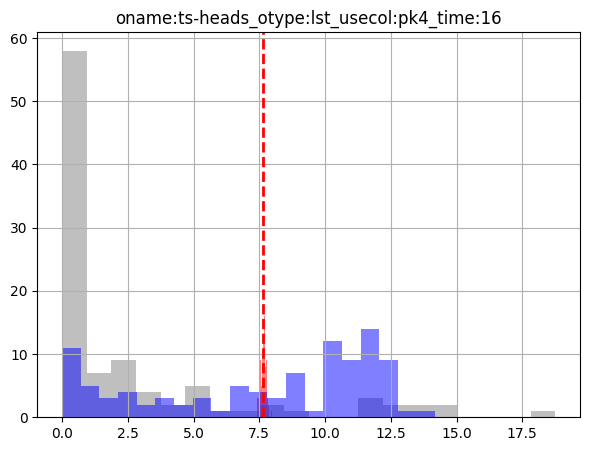

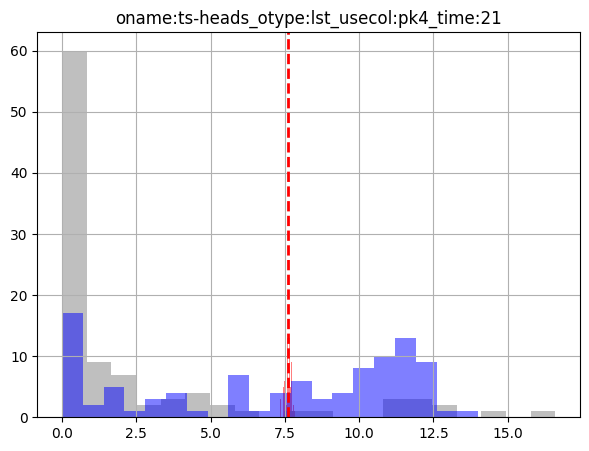

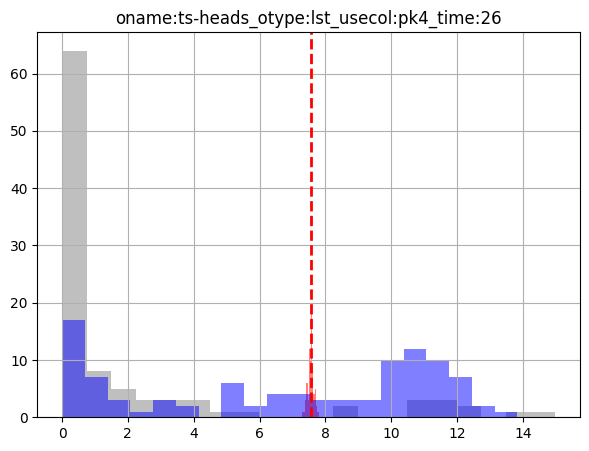

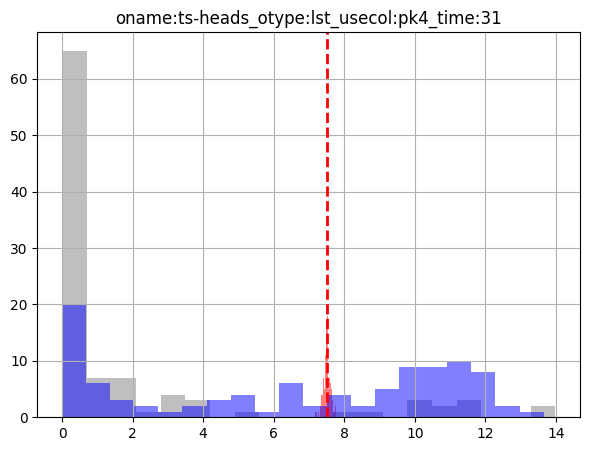

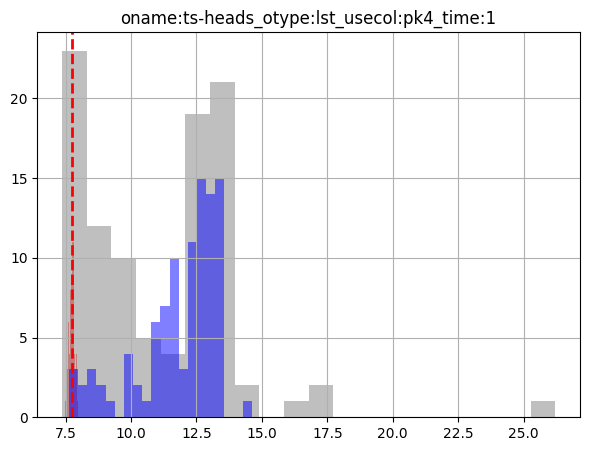

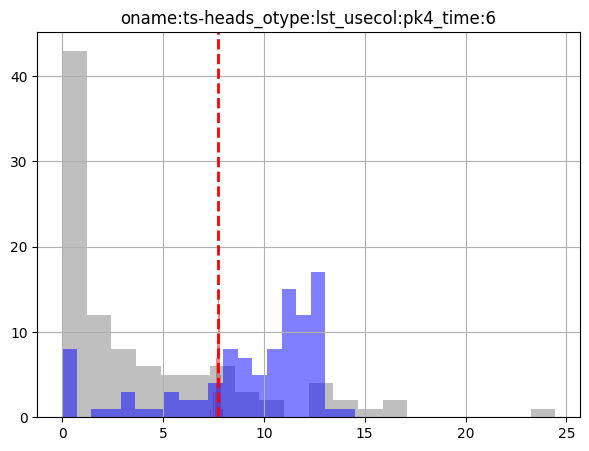

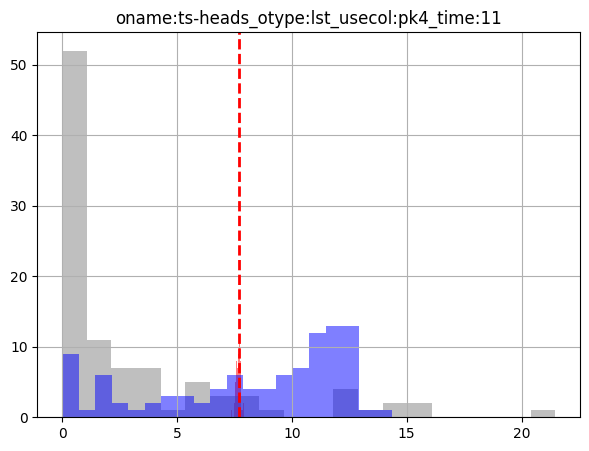

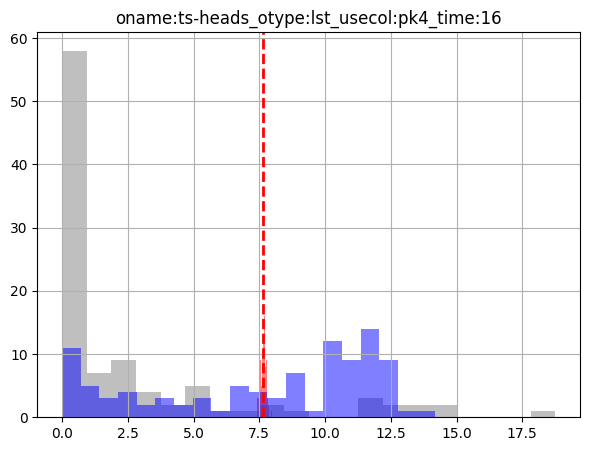

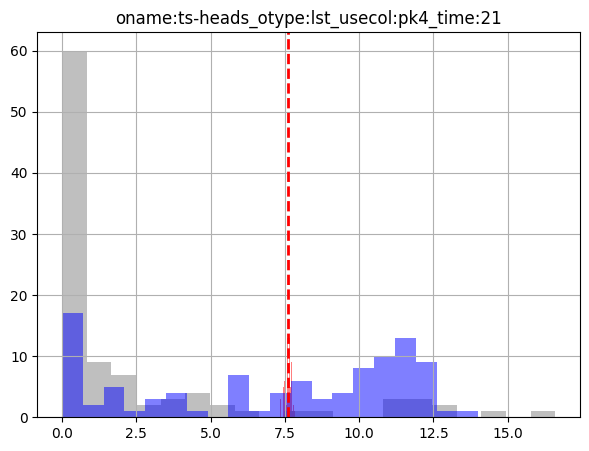

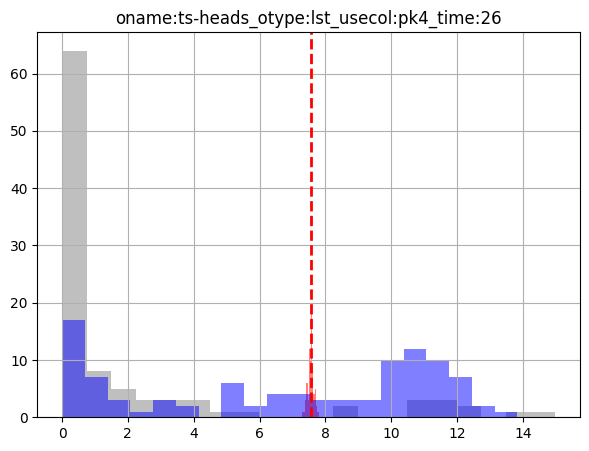

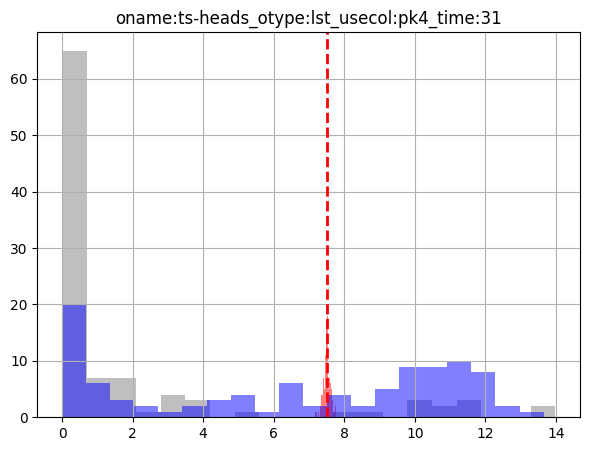

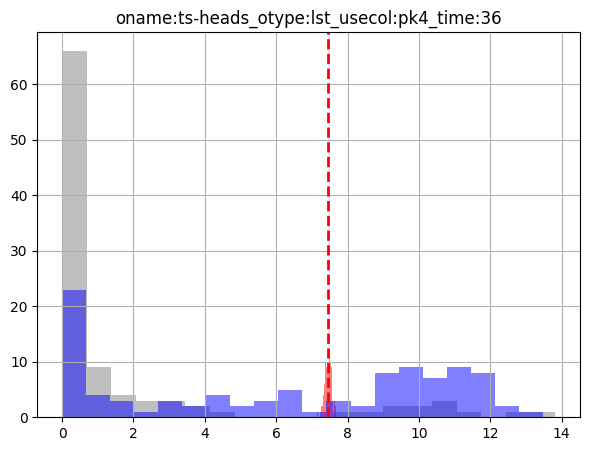

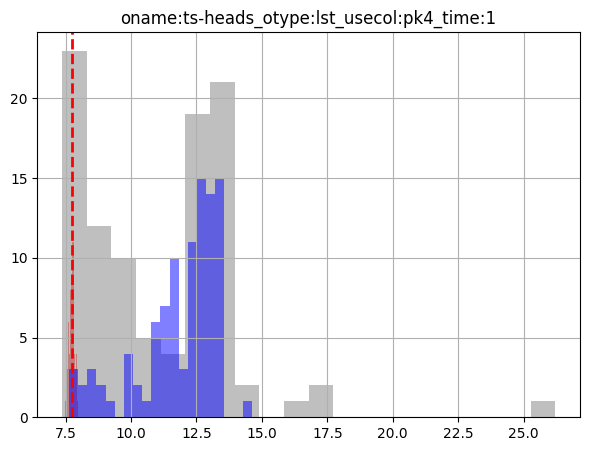

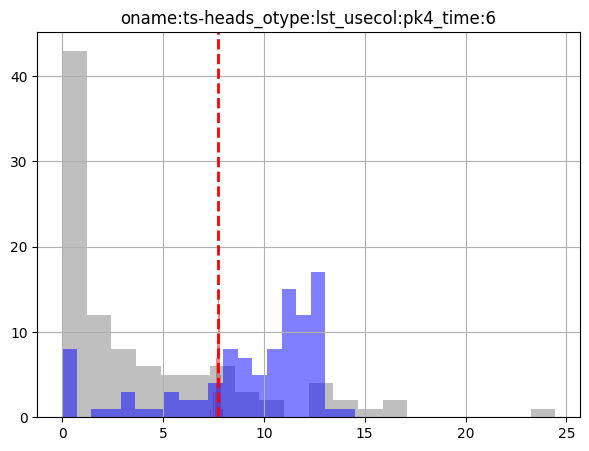

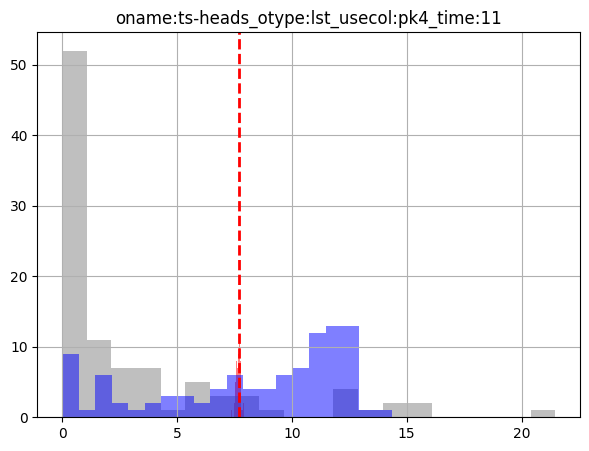

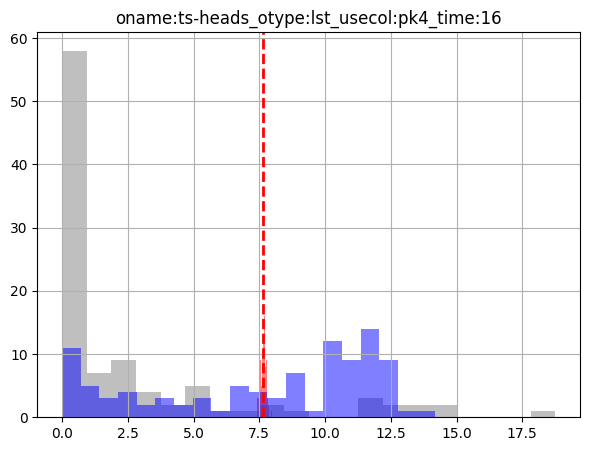

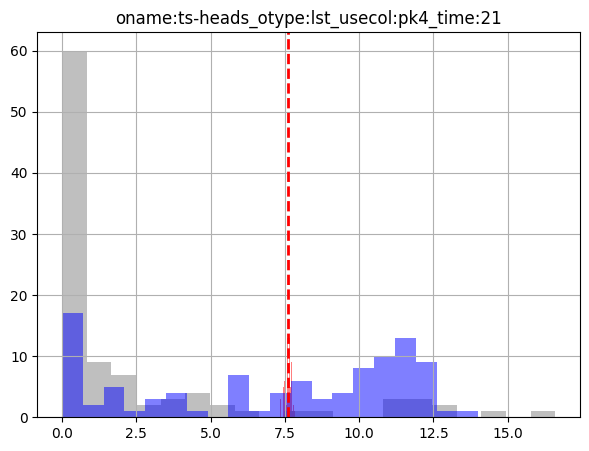

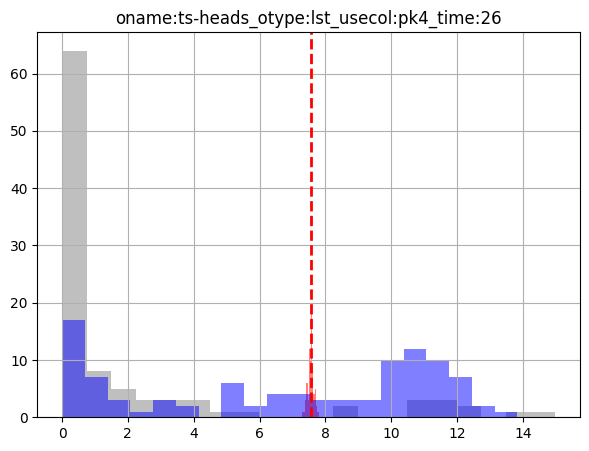

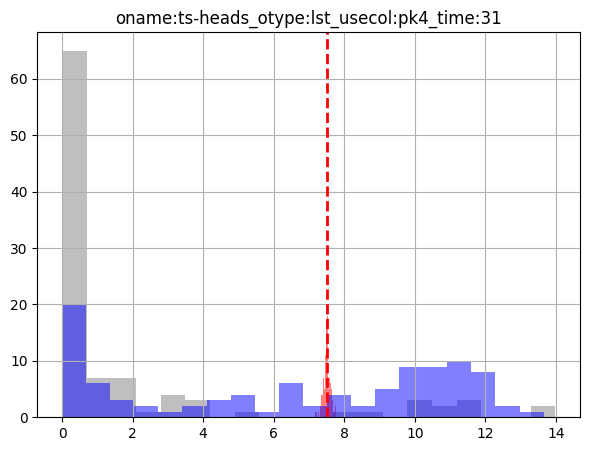

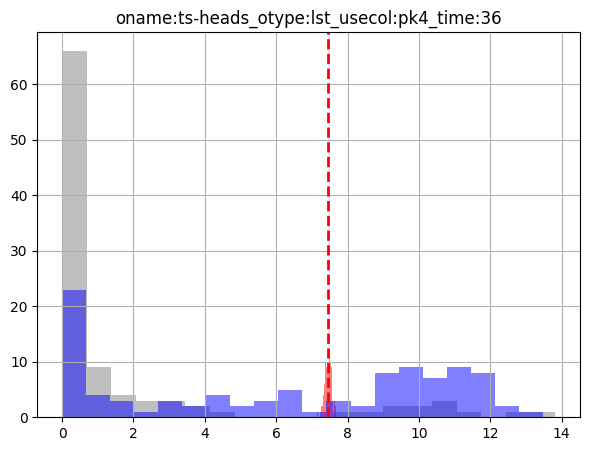

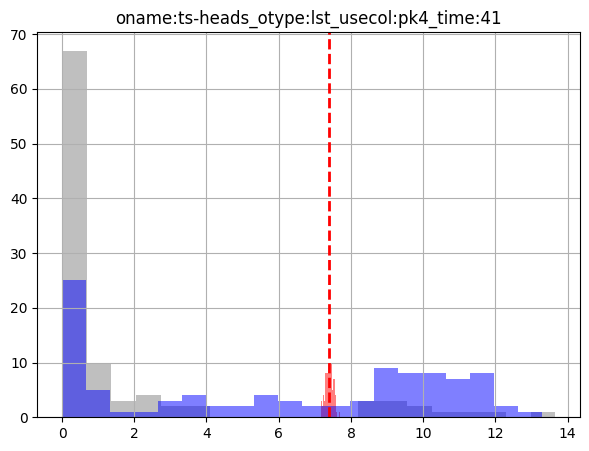

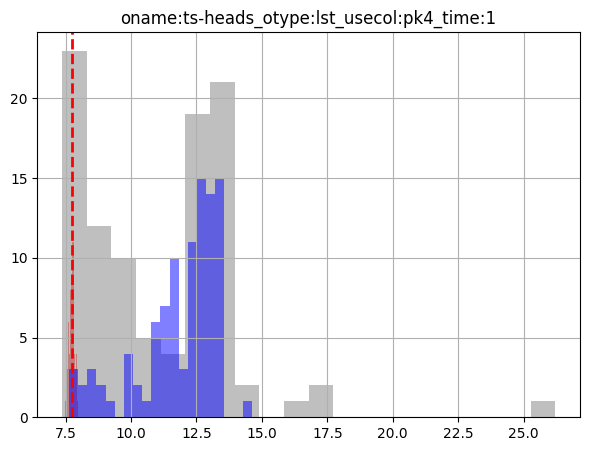

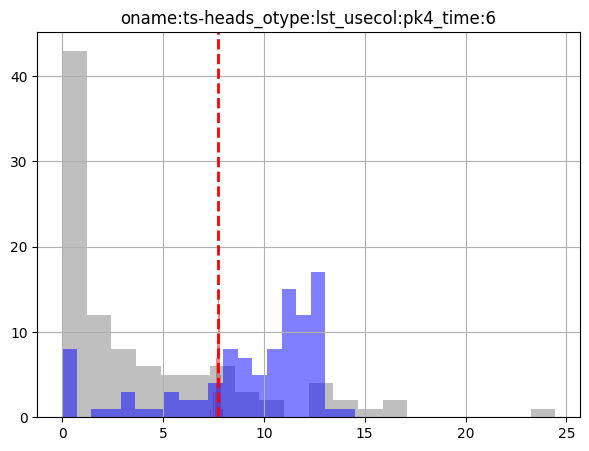

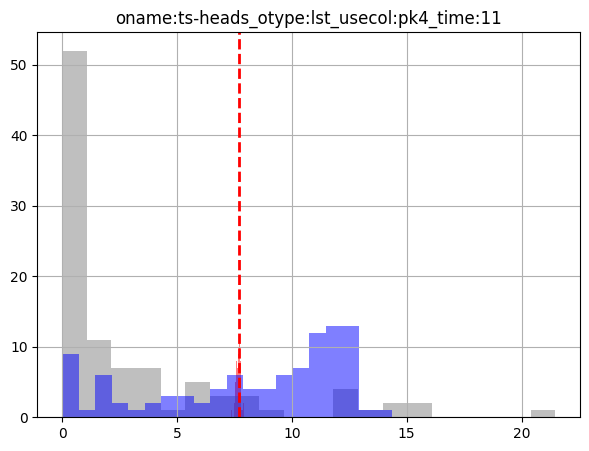

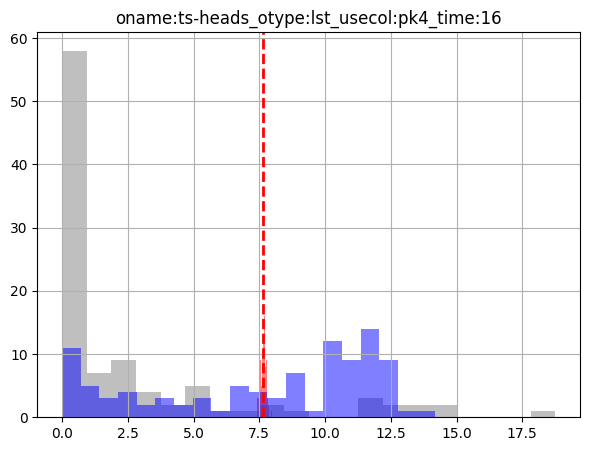

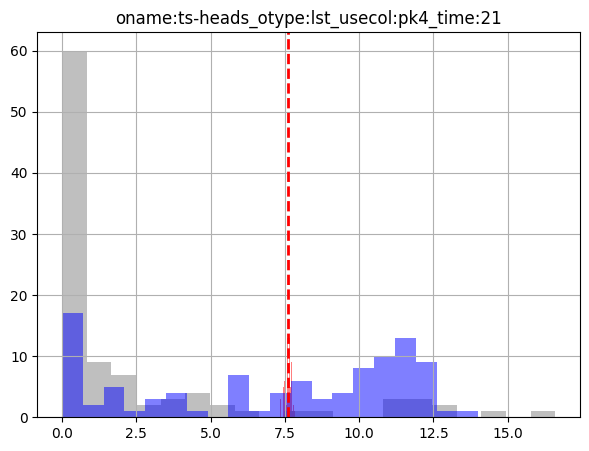

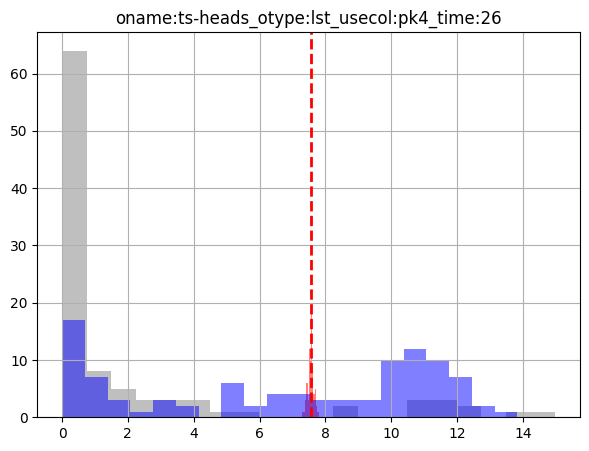

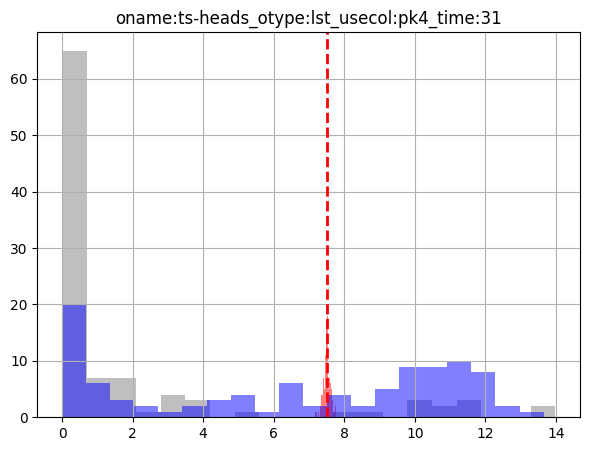

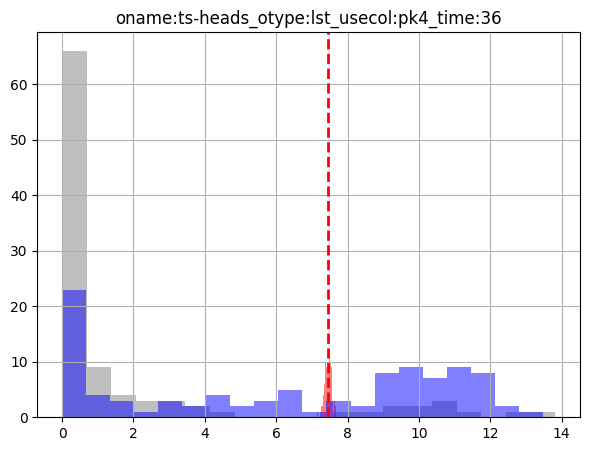

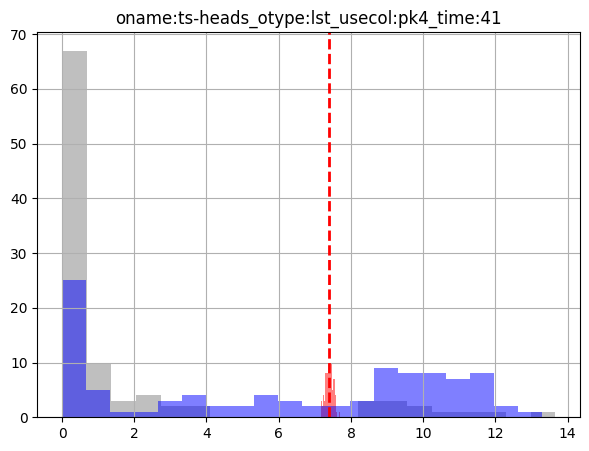

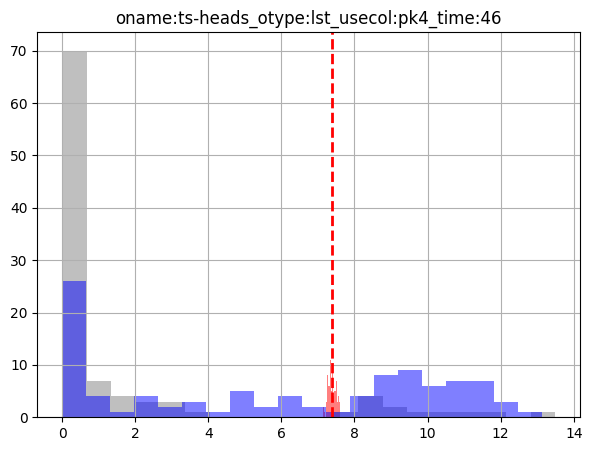

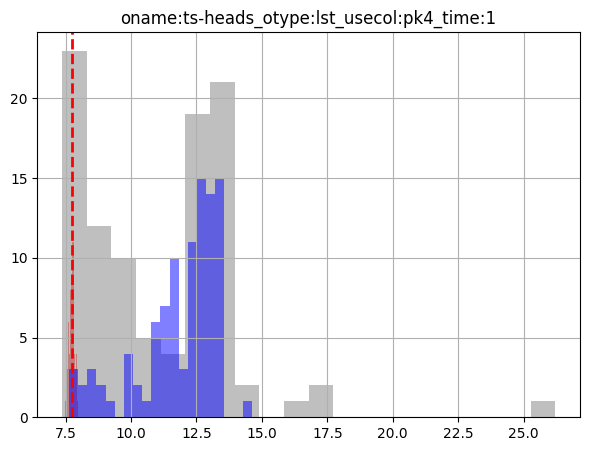

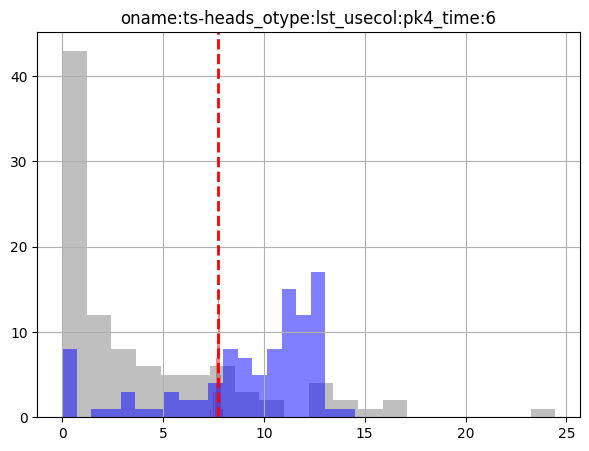

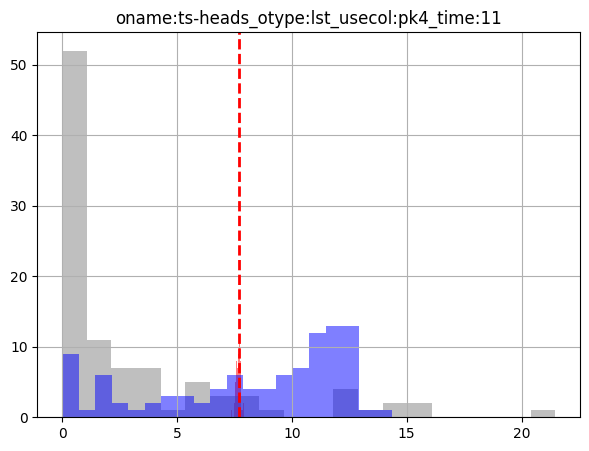

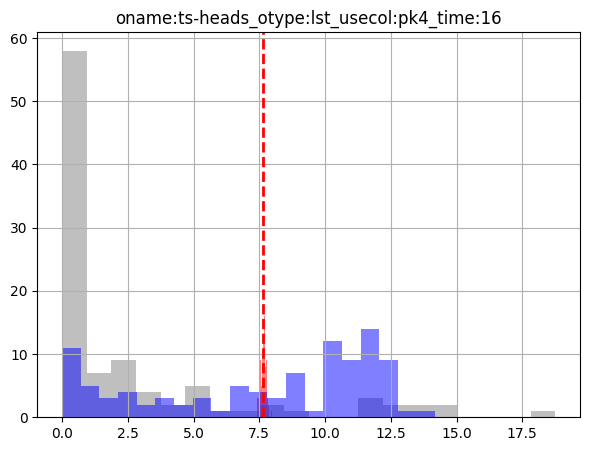

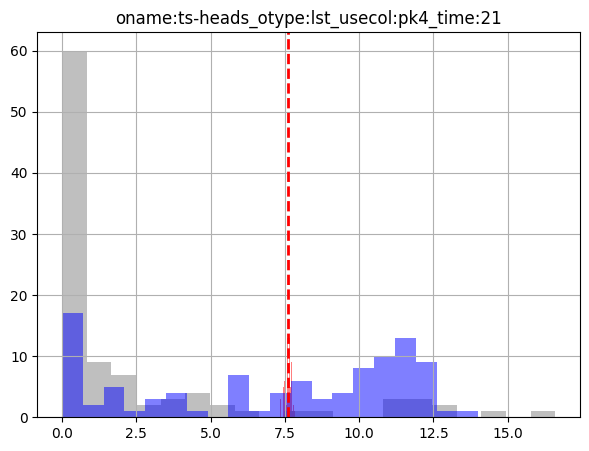

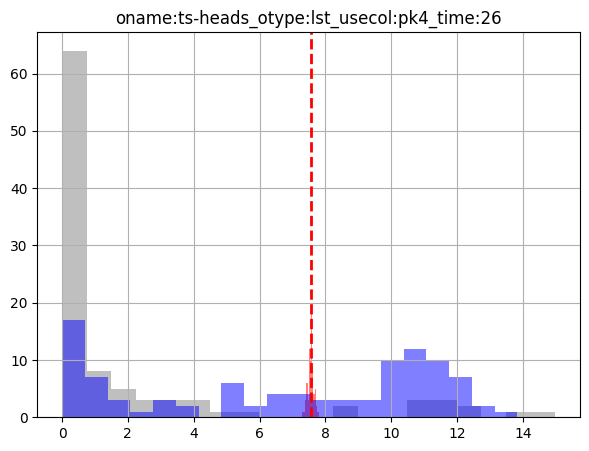

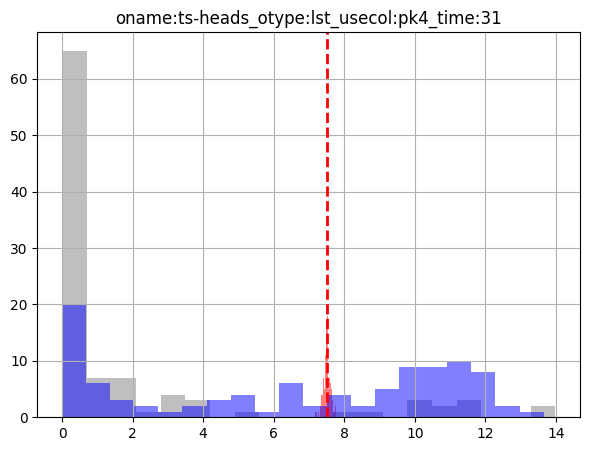

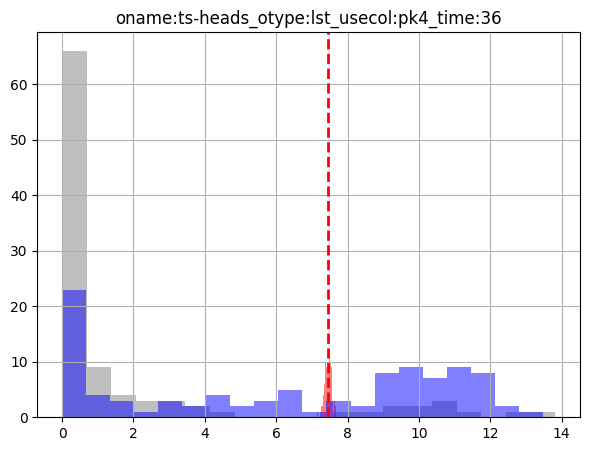

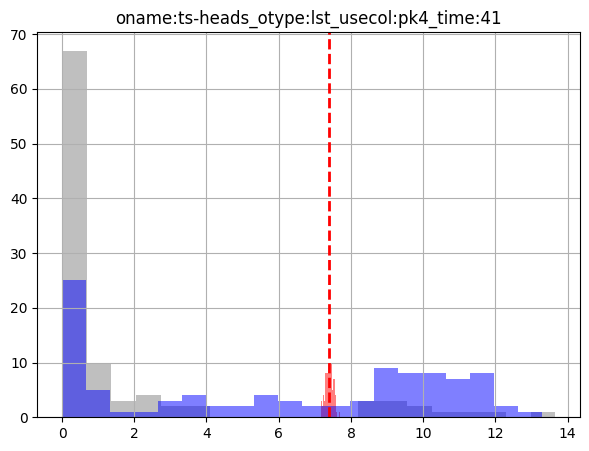

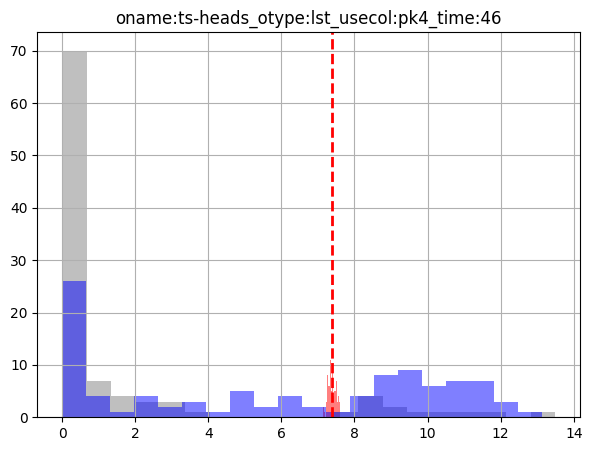

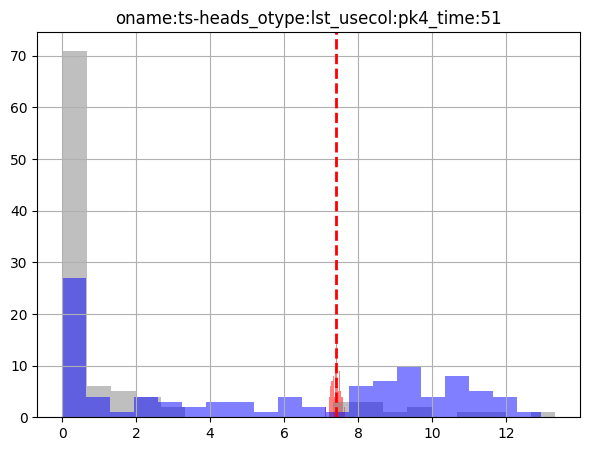

In [7]:
time = 1
colname = 'pk4'

for time in np.arange(1, 53, 5):
    col = f'oname:ts-heads_otype:lst_usecol:{colname}_time:{time}'
    bins=20
    fig, ax = plt.subplots(1,1,figsize=(7,5))

    # plot posterior/noise (red)
    ts_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

    # plot prior (blue)
    pre_oe_ts.loc[:,col].hist(ax=ax, fc="grey", alpha=0.5, bins=bins, label="Prior")
    pt_oe_ts.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Posterior")

    # add mean line for noise & prior
    meanp_val = pre_oe_ts.loc[:,col].mean()
    # ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
    mean_val = ts_noise.loc[:,col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

    ax.set_title(col)

### Plots

In [8]:
def format_tsdf(df):
    tdf = df.transpose()
    tdf['time'] = tdf.index.map(extract_time)
    tdf['usecol'] = tdf.index.map(extract_usecol)
    return tdf

ts_df = format_tsdf(pre_oe_ts)
ts_pt_df = format_tsdf(pt_oe_ts)

In [9]:
ts_df['usecol'].unique()

array(['pk4-conf-diff', 'pk4-spr-diff', 'pk4'], dtype=object)

### Timeseries (1st-99th)

In [10]:
ts_df

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,time,usecol
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:1,-5.812010,-0.769659,-1.483860,-0.833812,-1.27167,-6.309280,-6.499680,-1.233240,-2.843230,-5.129350,...,-4.57303,3.56583,-4.21393,-5.742110,-1.606860,-6.467670,-6.320560,-0.151822,1,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:10,-13.529800,-0.814745,-13.460800,-13.558800,-1.47866,-13.342900,-13.200900,-13.546700,-12.813600,-10.247000,...,-9.95039,2.30342,-10.61810,-7.151470,-13.130000,-13.517600,-13.536300,-0.954253,10,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:100,-13.014300,0.046704,-13.039400,-13.058900,-2.29374,-12.956500,-13.060000,-13.045500,-12.690800,-12.462900,...,-12.02290,-2.16742,-11.80220,-12.142800,-13.059300,-13.049900,-12.276500,-3.898990,100,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:101,-12.995900,0.029679,-13.021000,-13.040500,-2.32454,-12.938100,-13.041600,-13.027100,-12.672400,-12.455000,...,-12.02650,-2.25966,-11.78380,-12.164700,-13.040900,-13.031600,-12.278000,-3.968230,101,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:102,-12.977500,0.012764,-13.002600,-13.022100,-2.35511,-12.919800,-13.023200,-13.008800,-12.654000,-12.446200,...,-12.02860,-2.34899,-11.76540,-12.184600,-13.022500,-13.013200,-12.278300,-4.036560,102,pk4-conf-diff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oname:ts-heads_otype:lst_usecol:pk4_time:95,0.046056,13.285800,0.020970,0.001447,11.01610,0.103814,0.000318,0.014812,0.369653,0.667195,...,1.17477,11.49390,1.25814,1.151020,0.001043,0.010726,0.903636,9.613530,95,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:96,0.046056,13.249800,0.020970,0.001447,10.96570,0.103812,0.000318,0.014812,0.369616,0.650595,...,1.14317,11.36690,1.25814,1.099690,0.001042,0.010660,0.876555,9.521190,96,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:97,0.046056,13.214000,0.020969,0.001447,10.91560,0.103812,0.000318,0.014812,0.369619,0.635443,...,1.11379,11.24350,1.25814,1.050800,0.001041,0.010637,0.851094,9.429820,97,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:98,0.046056,13.178200,0.020969,0.001447,10.86570,0.103811,0.000318,0.014812,0.369594,0.621611,...,1.08646,11.12340,1.25814,1.004230,0.001040,0.010555,0.827316,9.339390,98,pk4


C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\5457106

C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\545710601.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_9412\5457106

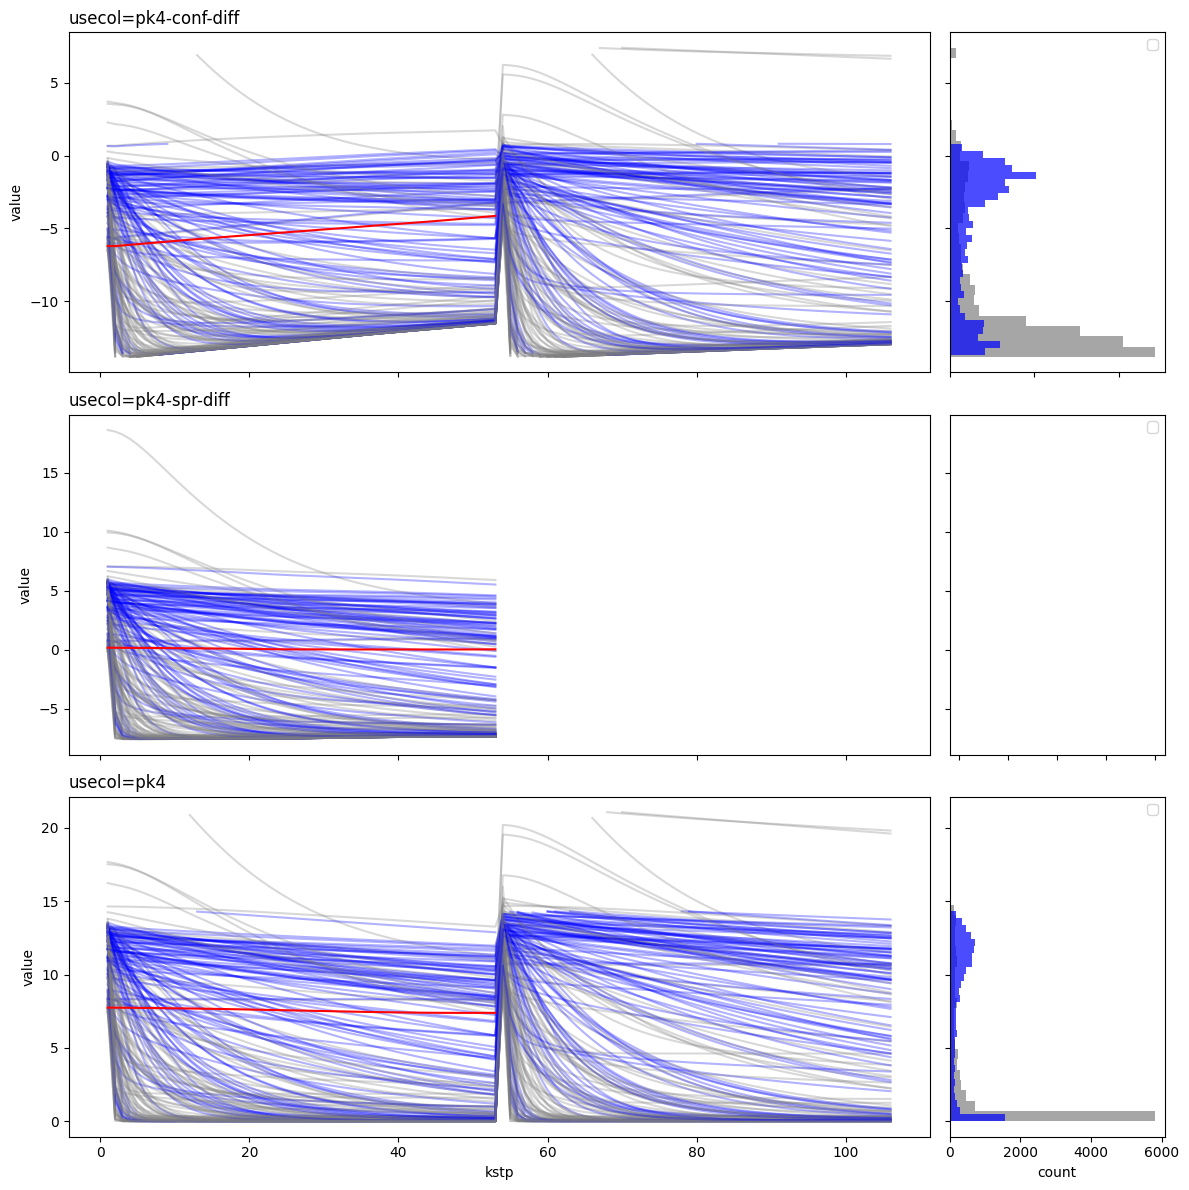

In [11]:
unique_usecols = ts_df['usecol'].unique()
n = len(unique_usecols)

fig = plt.figure(figsize=(12, n * 4))
gs = gridspec.GridSpec(n, 2, width_ratios=[4, 1])

axes = []
for i in range(n):
    if i == 0:
        ax0 = fig.add_subplot(gs[i, 0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    else:
        ax0 = fig.add_subplot(gs[i, 0], sharex=axes[0][0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    axes.append([ax0, ax1])

for idx, usecol in enumerate(unique_usecols):
    truth_col = truth_df[usecol]
    
    # prep
    df_sub = ts_df[(ts_df['usecol'] == usecol)].sort_values('time')
    df_pt_sub = ts_pt_df[(ts_pt_df['usecol'] == usecol)].sort_values('time')

    # if values are -999 replace with np.nana
    df_sub.replace(-999, np.nan, inplace=True)
    df_pt_sub.replace(-999, np.nan, inplace=True)

    value_cols = [col for col in df_sub.columns if col not in ['time', 'usecol']]
    all_values = df_sub[value_cols].values.flatten()
    all_values_pt = df_pt_sub[value_cols].values.flatten()
    lower, upper = np.percentile(all_values, [1, 99])
    lower_pt, upper_pt = np.percentile(all_values_pt, [1, 99])
    
    # line plot
    for col in value_cols:
        y = df_sub[col].copy()
        y_pt = df_pt_sub[col].copy()
        # mask outliers
        y[(y < lower) | (y > upper)] = np.nan
        y_pt[(y_pt < lower_pt) | (y_pt > upper_pt)] = np.nan
        # plot prio/posterior
        axes[idx][0].plot(df_sub['time'], y, alpha=0.3, color='grey')
        axes[idx][0].plot(df_pt_sub['time'], y_pt, alpha=0.3, color='blue')

    # plot truth
    axes[idx][0].plot(truth_col, alpha=1, color='red')
    
    axes[idx][0].set_title(f'usecol={usecol}', loc='left')
    axes[idx][0].set_ylabel('value')
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][0].set_xlabel('')
        axes[idx][0].tick_params(labelbottom=False)
    else:
        axes[idx][0].set_xlabel('kstp')
    
    # histogram
    filtered_values = all_values[(all_values >= lower) & (all_values <= upper)]
    filtered_values_pt = all_values_pt[(all_values_pt >= lower_pt) & (all_values_pt <= upper_pt)]

    axes[idx][1].hist(filtered_values, bins=30, alpha=0.7, color='gray', orientation='horizontal')
    axes[idx][1].hist(filtered_values_pt, bins=30, alpha=0.7, color='blue', orientation='horizontal')

    # mean_val = filtered_values.mean()
    # axes[idx][1].axhline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.2f}')
    # axes[idx][1].set_title(f'Distribution')
    axes[idx][1].tick_params(labelleft=False)
    
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][1].set_xlabel('')
        axes[idx][1].tick_params(labelbottom=False)
    else:
        axes[idx][1].set_xlabel('count')
    axes[idx][1].legend()

plt.tight_layout()

# save
fig.savefig(os.path.join(output, 'output.ts-heads_timeseries.png'), dpi=300)

plt.show()

## Subset realizations

In [13]:
truth_recession = truth_df['pk4']

In [170]:
print(truth_df['pk4'].mean())
truth_df.iloc[1]-truth_df.iloc[-1]

7.548625242513141


pk4              0.353372
pk4-spr-diff     0.128990
pk4-conf-diff   -2.075373
std              0.000000
weight           0.000000
dtype: float64

In [184]:
truth_df['pk4'].mean()

np.float64(7.548625242513141)

In [15]:
ts_pt_df = ts_pt_df.sort_values('time')

#### Prior subset

In [17]:
pk4_ts = ts_df[ts_df['usecol'] == 'pk4']
pk4_spring_ts = ts_df[ts_df['usecol'] == 'pk4-spr-diff']
pk4_conf_ts = ts_df[ts_df['usecol'] == 'pk4-conf-diff']

In [179]:
pk4_ts.loc[:,0:99].head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
oname:ts-heads_otype:lst_usecol:pk4_time:1,13.433141,7.620502,13.427437,11.822413,13.352597,12.159112,7.948337,8.572496,13.402509,13.295466,...,12.332420,9.411349,14.313412,13.785654,8.173135,13.585805,8.821427,8.910213,8.001190,15.263349
oname:ts-heads_otype:lst_usecol:pk4_time:10,13.005103,7.552746,13.394918,10.172461,12.913188,12.622439,7.996619,8.543756,12.551650,12.127963,...,10.792928,10.412060,14.733379,8.210849,2.205665,6.629195,11.205270,7.654560,8.189498,14.051597
oname:ts-heads_otype:lst_usecol:pk4_time:100,12.338668,9.926368,13.238790,7.481584,12.534107,11.232239,12.471528,9.566472,10.274608,7.700234,...,8.793531,9.402913,15.554115,3.336331,1.051130,3.562208,13.230683,5.245696,9.988216,10.656066
oname:ts-heads_otype:lst_usecol:pk4_time:101,12.318033,9.924968,13.228767,7.424290,12.515502,11.196595,12.462880,9.547911,10.222249,7.600828,...,8.765975,9.350170,15.553290,3.310064,1.051129,3.557192,13.232503,5.169267,9.982103,10.567181
oname:ts-heads_otype:lst_usecol:pk4_time:102,12.297439,9.923495,13.218725,7.368015,12.497444,11.161201,12.454238,9.528948,10.170438,7.502646,...,8.739040,9.297846,15.552475,3.285672,1.051128,3.552667,13.234190,5.095451,9.975940,10.479213


In [180]:
pk4_ts.loc[:,0:99].apply(lambda x: x.mean(), axis=0)

0     12.694796
1      8.704500
2     13.325234
3      8.870979
4     12.611615
        ...    
95     5.096851
96    12.547182
97     6.953051
98     9.135332
99    12.439754
Length: 100, dtype: float64

In [193]:
ts_df.iloc[1].iloc[0:100]

0    -0.553165
1    -6.005358
2    -0.149928
3    -3.398875
4    -0.647751
        ...   
95   -6.923234
96   -2.350526
97   -5.916805
98   -5.377828
99    0.491307
Name: oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:10, Length: 100, dtype: object

In [196]:
def get_subset(start, end, ts_df, col, less_than, greater_than, mean_val):
    # recessions
    ts_df = ts_df[ts_df['usecol'] == col]
    ts_r = ts_df.iloc[start].iloc[0:100] - ts_df.iloc[end].iloc[0:100]
    ts_mean = ts_df.iloc[:,0:100].apply(lambda x: x.mean(), axis=0)
    return ts_r[(ts_r < less_than) & (ts_r > greater_than) & (ts_mean < mean_val+2) & (ts_mean > mean_val-2)].index.to_list()

In [197]:
pk4_r = get_subset(0, 52, ts_df, 'pk4', 1, 0, truth_df['pk4'].mean())
pk4sp_r = get_subset(0, 52, ts_df, 'pk4-spr-diff', 0.5, 0, truth_df['pk4-spr-diff'].mean())
pk4cf_r = get_subset(0, 52, ts_df, 'pk4-conf-diff', -1, -3, truth_df['pk4-conf-diff'].mean())

# shows reals where numbers are in all lists
prior_reals = set(pk4_r) & set(pk4cf_r)
prior_reals_list = list(prior_reals)
prior_reals_list

[1, 7, 40, 74, 19, 24, 31]

In [198]:
pk4_r = get_subset(0, 52, ts_pt_df, 'pk4', 3, 0, truth_df['pk4'].mean())
pk4sp_r = get_subset(0, 52, ts_pt_df, 'pk4-spr-diff', 1, 0, truth_df['pk4-spr-diff'].mean())
pk4cf_r = get_subset(0, 52, ts_pt_df, 'pk4-conf-diff', 0, -5, truth_df['pk4-conf-diff'].mean())

# shows reals where numbers are in all lists
pt_reals = set(pk4_r) & set(pk4cf_r)
pt_reals_list = list(pt_reals)
pt_reals_list

[1, 98, 35, 6, 7, 40, 41, 74, 12, 44, 78, 79, 81, 52, 23, 24, 59, 31]

In [199]:
df_sub[prior_reals_list]

,1,7,40,74,19,24,31
oname:ts-heads_otype:lst_usecol:pk4_time:1,7.620502,8.572496,7.554544,7.528943,7.737083,8.556061,7.674618
oname:ts-heads_otype:lst_usecol:pk4_time:2,7.600397,8.556602,7.535338,7.528851,7.546491,8.584520,7.674535
oname:ts-heads_otype:lst_usecol:pk4_time:3,7.588508,8.548956,7.518429,7.529534,7.444439,8.592637,7.674453
oname:ts-heads_otype:lst_usecol:pk4_time:4,7.579969,8.546012,7.502887,7.530308,7.399547,8.594416,7.674372
oname:ts-heads_otype:lst_usecol:pk4_time:5,7.573352,8.545447,7.488515,7.530878,7.381879,8.593152,7.674291
...,...,...,...,...,...,...,...
oname:ts-heads_otype:lst_usecol:pk4_time:102,9.923495,9.528948,9.461019,9.345880,8.502465,10.081033,9.307412
oname:ts-heads_otype:lst_usecol:pk4_time:103,9.921952,9.509603,9.454547,9.341282,8.478945,10.074571,9.308292
oname:ts-heads_otype:lst_usecol:pk4_time:104,9.920341,9.489892,9.448082,9.336674,8.455458,10.068114,9.309158
oname:ts-heads_otype:lst_usecol:pk4_time:105,9.918663,9.469836,9.441623,9.332057,8.432007,10.061663,9.310012


C:\Users\tfo46\AppData\Local\Temp\ipykernel_18688\2026112345.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_18688\2026112345.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_18688\2026112345.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


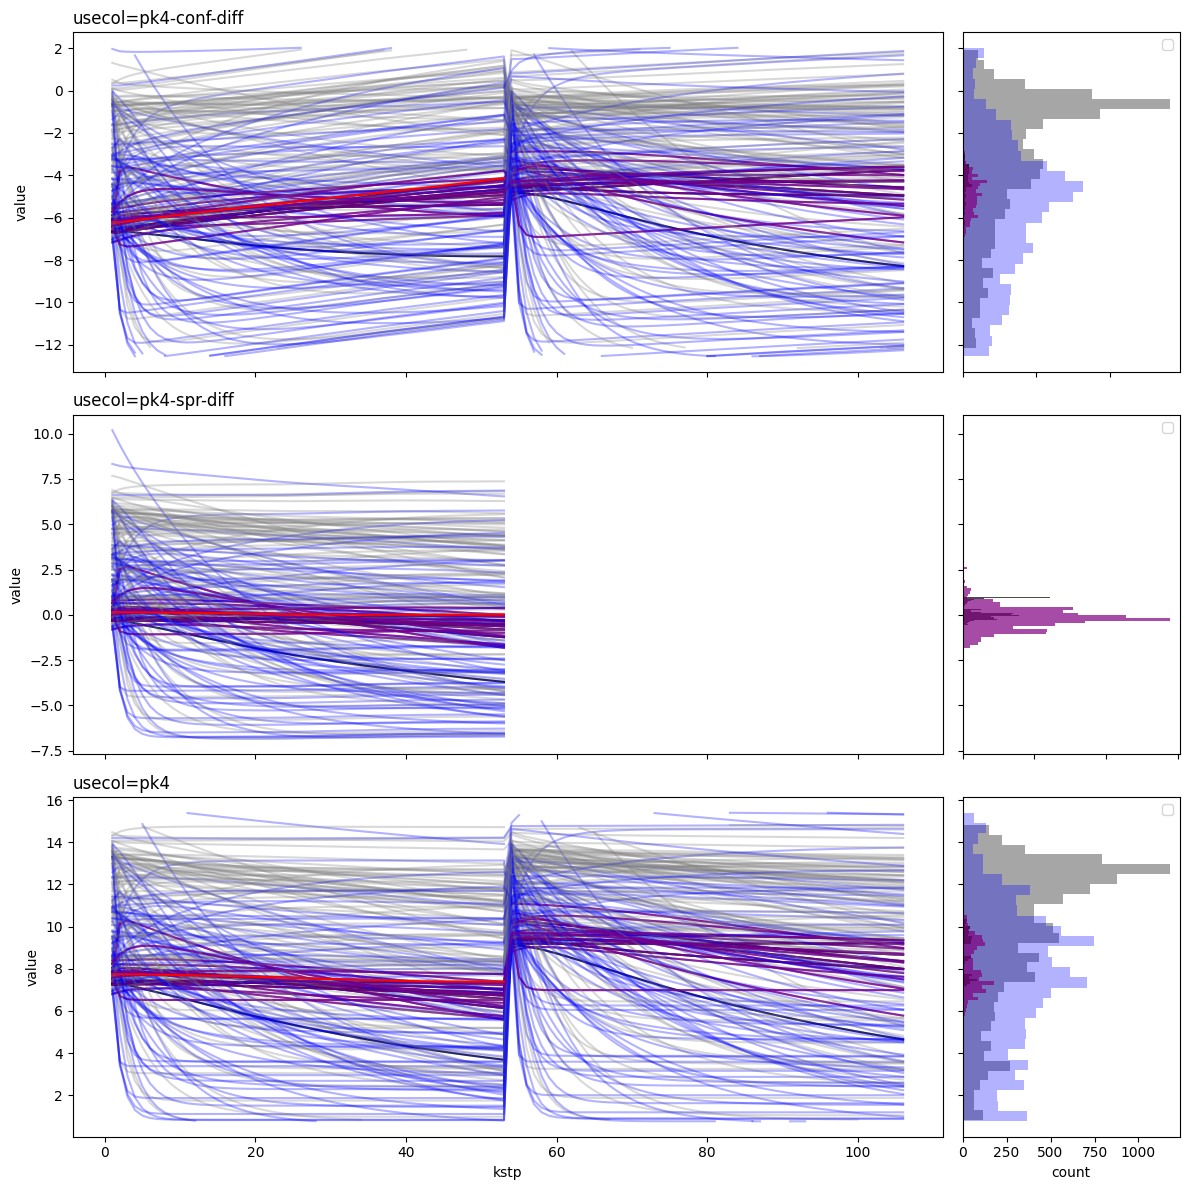

In [201]:
unique_usecols = ts_df['usecol'].unique()
n = len(unique_usecols)

fig = plt.figure(figsize=(12, n * 4))
gs = gridspec.GridSpec(n, 2, width_ratios=[4, 1])

axes = []
for i in range(n):
    if i == 0:
        ax0 = fig.add_subplot(gs[i, 0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    else:
        ax0 = fig.add_subplot(gs[i, 0], sharex=axes[0][0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    axes.append([ax0, ax1])

for idx, usecol in enumerate(unique_usecols):
    truth_col = truth_df[usecol]
    
    # prep
    df_sub = ts_df[(ts_df['usecol'] == usecol)].sort_values('time')
    df_pt_sub = ts_pt_df[(ts_pt_df['usecol'] == usecol)].sort_values('time')

    # if values are -999 replace with np.nana
    df_sub.replace(-999, np.nan, inplace=True)
    df_pt_sub.replace(-999, np.nan, inplace=True)

    value_cols = [col for col in df_sub.columns if col not in ['time', 'usecol']]
    
    all_values = df_sub[value_cols].values.flatten()
    all_values_pt = df_pt_sub[value_cols].values.flatten()
    
    pr_values = df_sub[prior_reals_list].values.flatten()
    pt_values = df_pt_sub[pt_reals_list].values.flatten()

    lower, upper = np.percentile(all_values, [1, 99])
    lower_pt, upper_pt = np.percentile(all_values_pt, [1, 99])

    
    # line plot
    for col in value_cols:
        y = df_sub[col].copy()
        y_pt = df_pt_sub[col].copy()
        # mask outliers
        y[(y < lower) | (y > upper)] = np.nan
        y_pt[(y_pt < lower_pt) | (y_pt > upper_pt)] = np.nan
        
        # plot prio/posterior
        axes[idx][0].plot(df_sub['time'], y, alpha=0.3, color='grey')
        if col in prior_reals_list:
            axes[idx][0].plot(df_sub['time'], y_pt, alpha=0.8, color='black')
        axes[idx][0].plot(df_pt_sub['time'], y_pt, alpha=0.3, color='blue')
        if col in pt_reals_list:
            axes[idx][0].plot(df_pt_sub['time'], y_pt, alpha=0.8, color='purple')
    # plot truth
    axes[idx][0].plot(truth_col, alpha=1, color='red')
    
    axes[idx][0].set_title(f'usecol={usecol}', loc='left')
    axes[idx][0].set_ylabel('value')
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][0].set_xlabel('')
        axes[idx][0].tick_params(labelbottom=False)
    else:
        axes[idx][0].set_xlabel('kstp')
    
    # histogram
    filtered_values = all_values[(all_values >= lower) & (all_values <= upper)]
    filtered_values_pt = all_values_pt[(all_values_pt >= lower_pt) & (all_values_pt <= upper_pt)]

    axes[idx][1].hist(filtered_values, bins=30, alpha=0.7, color='gray', orientation='horizontal')
    axes[idx][1].hist(filtered_values_pt, bins=30, alpha=0.3, color='blue', orientation='horizontal')
    
    axes[idx][1].hist(pr_values, bins=30, alpha=0.7, color='black', orientation='horizontal')
    axes[idx][1].hist(pt_values, bins=30, alpha=0.7, color='purple', orientation='horizontal')
    # mean_val = filtered_values.mean()
    # axes[idx][1].axhline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.2f}')
    # axes[idx][1].set_title(f'Distribution')
    axes[idx][1].tick_params(labelleft=False)
    
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][1].set_xlabel('')
        axes[idx][1].tick_params(labelbottom=False)
    else:
        axes[idx][1].set_xlabel('count')
    axes[idx][1].legend()

plt.tight_layout()

# save
fig.savefig(os.path.join(output, 'output.ts-heads_timeseries.png'), dpi=300)

plt.show()

## Awanui Flux vs PK4 Head 

In [52]:
idf = ts_df[
    (ts_df['kper'] == 1) \
        & (ts_df['kstp'] == 1)
    ].sort_values('kstp')
col_df = idf.set_index('usecol').transpose()[:-2]

KeyError: 'kper'

In [102]:
col_df.columns

Index(['awcum', 'awgwhead', 'awq', 'awswgwdiff', 'awswhead', 'awtot',
       'confhead', 'firstnegday', 'pk4awgwdiff', 'pk4awswdiff', 'pk4confdiff',
       'pk4head', 'pk4pwgwdiff', 'pk4pwswdiff', 'pk4springdiff', 'pwcum',
       'pwgwhead', 'pwq', 'pwswgwdiff', 'pwswhead', 'pwtot', 'springcum',
       'springhead', 'springq'],
      dtype='object', name='usecol')

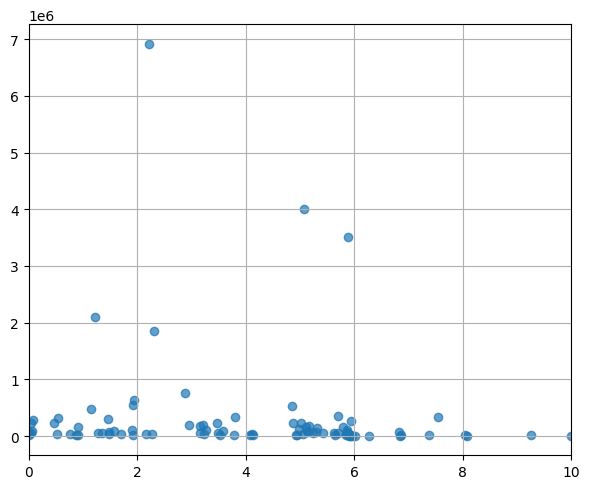

In [109]:
# Example: scatter plot of the first two columns in col_df
col_names = col_df.columns[:2]
plt.figure(figsize=(6, 5))
plt.scatter(col_df['pk4springdiff'], col_df['awtot']*-1, alpha=0.7)
plt.xlim(0,10)
# plt.ylim(-250,5)
plt.tight_layout()
plt.grid()
plt.show()

In [111]:
idf = ts_df[
    (ts_df['kper'] == 2) \
        # & (ts_df['kstp'] == 1)
    ].sort_values('kstp')
# col_df = idf.set_index('usecol').transpose()

In [112]:
idf

,0,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,kper,kstp,usecol
oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:1,-1.293550,-978.099000,-1.012570e+06,-63418.900000,-4368.160000,-6.340010,-805.55300,-17683.800000,-4862.280000,-274.06600,...,-33.59480,-6468.42000,-105.059000,-16.979100,-233.55400,-3.536430,-1660.40000,2,1,awcum
oname:timeseries_otype:lst_usecol:awgwhead_kper:2_kstp:1,10.474700,0.095069,1.324580e+00,1.940700,3.780560,7.120300,11.07160,0.122775,0.672726,11.27250,...,10.58750,6.95799,0.808224,0.000158,12.92110,0.744205,13.72630,2,1,awgwhead
oname:timeseries_otype:lst_usecol:springq_kper:2_kstp:1,-222.231000,-0.009939,-5.362380e+03,-21.751400,-0.049880,-15766.300000,-1.22625,-0.052209,-489.582000,-0.05281,...,-4.40266,-3.75349,-0.000506,-0.005282,-132.33100,-0.003670,-13.74300,2,1,springq
oname:timeseries_otype:lst_usecol:springcum_kper:2_kstp:1,-858.969000,-0.179910,-6.014760e+05,-376.032000,-0.514329,-72053.900000,-1202.98000,-1.397330,-6261.390000,-2.00784,...,-343.47600,-67.77720,-4.895820,-0.012125,-1076.91000,-0.588835,-164.83500,2,1,springcum
oname:timeseries_otype:lst_usecol:springhead_kper:2_kstp:1,7.593460,7.593460,7.593460e+00,7.593460,7.593460,7.593460,7.59346,7.593460,7.593460,7.59346,...,7.59346,7.59346,7.593460,7.593460,7.59346,7.593460,7.59346,2,1,springhead
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oname:timeseries_otype:lst_usecol:pwtot_kper:2_kstp:51,-4055.390000,-1894.770000,-2.041010e+03,-1893.610000,-1916.460000,-1910.680000,-2777.42000,-2048.040000,-2076.820000,-15671.00000,...,-15505.40000,-2127.57000,-1915.540000,-1902.740000,-21768.60000,-1893.550000,-2096.60000,2,51,pwtot
oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:51,-0.624075,-21.914300,-2.242470e+03,-179.515000,-22.075600,-1.258800,-15.45050,-883.706000,-520.948000,-76.51300,...,-1.18165,-686.40400,-0.200835,-0.037006,-81.78840,-0.370422,-980.36500,2,51,awcum
oname:timeseries_otype:lst_usecol:pwcum_kper:2_kstp:51,-2161.920000,-1.298970,-1.475420e+02,-0.143050,-22.987900,-17.215300,-883.95000,-154.575000,-183.357000,-13777.50000,...,-13612.00000,-234.10100,-22.070300,-9.273770,-19875.10000,-0.080918,-203.12800,2,51,pwcum
oname:timeseries_otype:lst_usecol:firstnegday_kper:2_kstp:51,2.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,4.00000,1.000000,1.000000,8.00000,...,4.00000,1.00000,1.000000,1.000000,19.00000,1.000000,-1.00000,2,51,firstnegday


### All plots

In [124]:
dfs = {}
for i in idf['kstp'].unique():
    kstp_df = idf[idf['kstp'] == i]
    dfs[i] = kstp_df.set_index('usecol').transpose()[:-2]

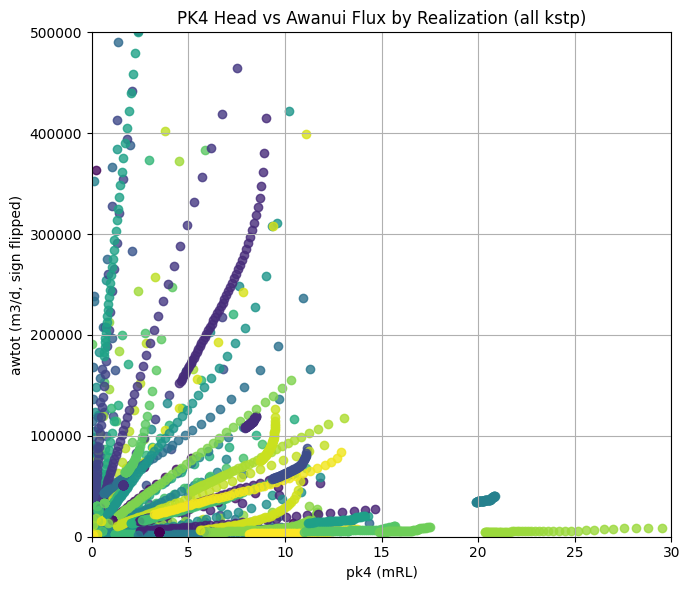

In [134]:
plt.figure(figsize=(7, 6))

# Use realization index for color, all points have the same marker shape
for nstp in dfs.keys():
    ndf = dfs[nstp]
    colors = plt.cm.viridis(np.linspace(0, 1, len(ndf)))
    for i, (idx, row) in enumerate(ndf.iterrows()):
        plt.scatter(row['pk4head'], -row['awtot'],
                    color=colors[i],
                    marker='o',  # same shape for all
                    alpha=0.8)

plt.xlabel('pk4 (mRL)')
plt.ylabel('awtot (m3/d, sign flipped)')
plt.title('PK4 Head vs Awanui Flux by Realization (all kstp)')
plt.xlim(0, 30)
plt.ylim(0, 500000) 
plt.tight_layout()
plt.grid()
plt.show()

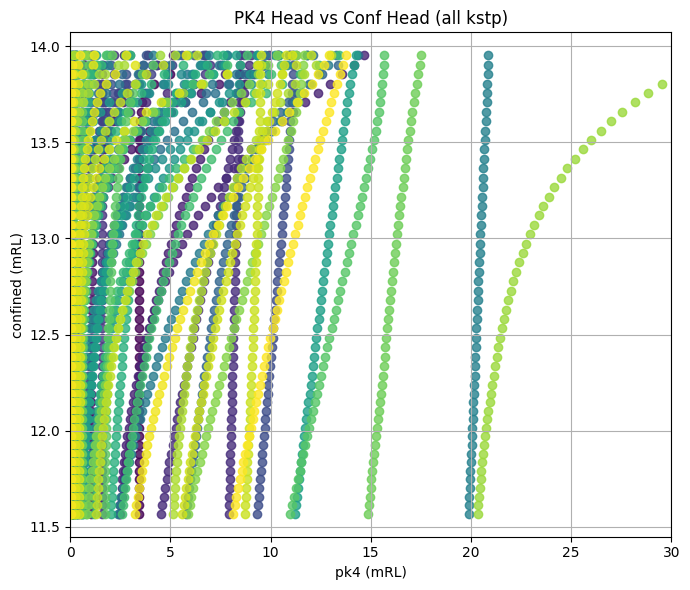

In [157]:
plt.figure(figsize=(7, 6))

# Use realization index for color, all points have the same marker shape
for nstp in dfs.keys():
    ndf = dfs[nstp]
    colors = plt.cm.viridis(np.linspace(0, 1, len(ndf)))
    for i, (idx, row) in enumerate(ndf.iterrows()):
        plt.scatter(row['pk4head'], row['confhead'],
                    color=colors[i],
                    marker='o',  # same shape for all
                    alpha=0.8)

plt.xlabel('pk4 (mRL)')
plt.ylabel('confined (mRL)')
plt.title('PK4 Head vs Conf Head (all kstp)')
plt.xlim(0, 30)
# plt.ylim(0, 500000) 
plt.tight_layout()
plt.grid()
plt.show()

## Timeseries (Awanui Q)

### Prep

In [107]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:awq')]

# data
pre_oe_ts = pd.read_csv(pr_oe_fn, usecols=desired_cols)
ts_noise = pd.read_csv(noise_fn, usecols=desired_cols)

In [108]:
desired_cols[:10]

['oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:50',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:51',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:48',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:49',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:46',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:47',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:9']

### Diagnostics

Text(0.5, 1.0, 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42')

Text(0.5, 1.0, 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42')

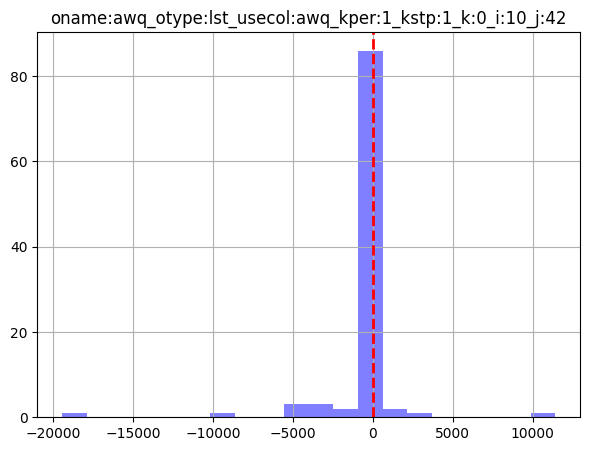

In [109]:
col = f'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42'
bins=20
fig, ax = plt.subplots(1,1,figsize=(7,5))

# plot posterior/noise (red)
ts_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
pre_oe_ts.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pre_oe_ts.loc[:,col].mean()
# ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = ts_noise.loc[:,col].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

## Params

### Setup

In [7]:
par_df = pd.read_csv(par_data_fn, index_col=0)
pr_pe = pd.read_csv(pr_pe_fn, index_col=0)
pt_pe = pd.read_csv(pt_pe_fn, index_col=0)

pr_peT = pd.merge(pr_pe, par_df, left_index=True, right_index=True)
pt_peT = pd.merge(pt_pe, par_df, left_index=True, right_index=True)

temp_arr = np.loadtxt(r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\models\local_run26\pest\master_ies\org\local_run26.rcha_recharge_0.txt")

param_headers = pr_pe.columns.tolist()

C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\1295918070.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\1295918070.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [8]:
par_df['pargp'].unique()

array(['npfklayer1-gr', 'npfklayer1-pp', 'npfklayer1-cn',
       'stosslayer1-gr', 'stosslayer1-pp', 'stosslayer1-cn',
       'rcharecharge0-gr', 'rcharecharge0-pp', 'rcharecharge0-cn',
       'ghbaw-cond-gr', 'ghbaw-cond-cn', 'ghbaw-head-hg', 'ghbaw-head-cn',
       'ghbpw-cond-gr', 'ghbpw-cond-cn', 'ghbpw-head-hg', 'ghbpw-head-cn',
       'ghbspring-cond-gr', 'ghbspring-cond-cn', 'ghbspring-head-hg',
       'ghbspring-head-cn', 'ghbconf-cond-gr', 'ghbconf-cond-cn',
       'ghbconf-head-hg', 'ghbconf-head-cn'], dtype=object)

In [9]:
par_pr_df.iloc[common_reals_list]

NameError: name 'par_pr_df' is not defined

In [10]:
pargps = par_df['pargp'].unique().tolist()

dfs = {}
for parg in pargps:
    if parg[:3] in ['npf', 'rch', 'sto']:
        cols = []
        idx = 'constant'
        if 'cn' in parg:
            idx = 'constant'
            cols = [p for p in param_headers if p.startswith(f'pname:{parg[:-2]}-cn')]
        elif 'pp' in parg:
            idx = 'pp'
            cols = [p for p in param_headers if p.startswith(f'pname:{parg[:-2]}-pp')]
        elif 'fngr' in parg:
            idx = 'fngr'
            cols = [p for p in param_headers if p.startswith(f'pname:{parg[:-4]}-fngr')]
        elif 'crgr' in parg:
            idx = 'crgr'
            cols = [p for p in param_headers if p.startswith(f'pname:{parg[:-4]}-crgr')]
    else:
        cols = [p for p in param_headers if p.startswith(f'pname:{parg}')]
    dfs[parg] = to_par_df(par_pr_df[cols], parg, idx)

NameError: name 'to_par_df' is not defined

In [229]:
arrs = {}
i = 'npfklayer1pp'
idf = dfs[i]
ptype = idf['ptype'].unique()[0]
i_arrs = []
for real in idf.columns[:-4]:
    arr = np.ones_like(temp_arr)
    if ptype == 'cn':
        val = idf[real].values[0]
        arr = np.ones_like(temp_arr) * val
    elif ptype in ['pp', 'fngr', 'crgr']:
        #  for idx, row in idf.iterrows():
        #     i_idx = row['i']
        #     j_idx = row['j']
        #     val = row[real]
        #     arr[i_idx, j_idx] = val
        arr = idf.pivot(index='i', columns='j', values=real).to_numpy()
        max_nan = 1e+30
        arr = np.where(arr == max_nan, np.nan, arr)
    i_arrs.append(arr)
i_stack = np.stack(i_arrs)
arrs[i] = {
    'i_stack': i_stack,
    'mean': np.mean(i_stack, axis=0),
    'min': np.min(i_stack, axis=0),
    'max': np.max(i_stack, axis=0),
    'std': np.std(i_stack, axis=0),
}

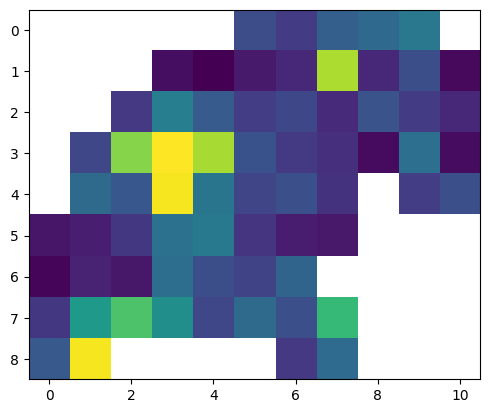

In [230]:
plt.imshow(arrs[i]['i_stack'][56])

In [242]:
# get all the heads into an array which we can now call to plot
arrs = {}
for i in dfs.keys():
    idf = dfs[i]
    ptype = idf['ptype'].unique()[0]
    i_arrs = []
    for real in idf.columns[:-4]:
        arr = np.ones_like(temp_arr) * np.nan
        if ptype == 'cn':
            val = idf[real].values[0]
            arr = np.ones_like(temp_arr) * val
        elif ptype in ['pp', 'fngr', 'crgr']:
             for idx, row in idf.iterrows():
                i_idx = row['i']
                j_idx = row['j']
                val = row[real]
                arr[i_idx, j_idx] = val
            # arr = idf.pivot(index='i', columns='j', values=real).to_numpy()
            # max_nan = 1e+30
        arr = np.where(arr == max_nan, np.nan, arr)
        i_arrs.append(arr)
    i_stack = np.stack(i_arrs)
    arrs[i] = {
        'i_stack': i_stack,
        'mean': np.mean(i_stack, axis=0),
        'min': np.min(i_stack, axis=0),
        'max': np.max(i_stack, axis=0),
        'std': np.std(i_stack, axis=0),
    }

#### interpolate

In [252]:
from scipy.interpolate import griddata

# Create array with NaN values
arr = arrs['npfklayer1pp']['i_stack'][56].copy()

# Get coordinates of valid (non-NaN) points
valid_mask = ~np.isnan(arr)
points = np.column_stack(np.where(valid_mask))
values = arr[valid_mask]

# Get coordinates of all points
all_i, all_j = np.mgrid[0:arr.shape[0], 0:arr.shape[1]]
xi = np.column_stack([all_i.ravel(), all_j.ravel()])

# Interpolate using nearest neighbor
filled_arr = griddata(points, values, xi, method='nearest').reshape(arr.shape)

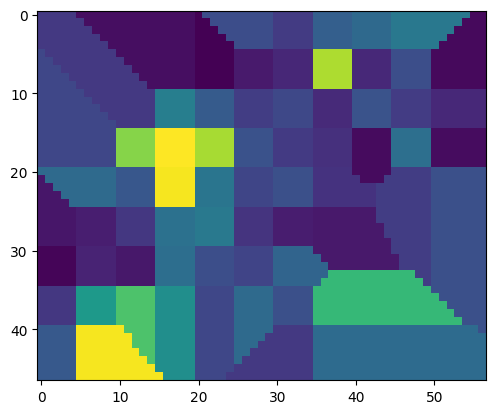

In [253]:
plt.imshow(filled_arr)

### plots

In [294]:
dfs.keys()

dict_keys(['npfklayer1pp', 'npfklayer1cn', 'stosslayer1pp', 'stosslayer1cn', 'rchfngr', 'rchpp', 'rchcn', 'ghb-aw-cond-fngr', 'ghb-aw-cond-crgr', 'ghb-aw-cond-cn', 'ghb-pw-cond-fngr', 'ghb-pw-cond-crgr', 'ghb-pw-cond-cn', 'ghb-spring-cond-fngr', 'ghb-spring-cond-crgr', 'ghb-spring-cond-cn', 'ghb-conf-cond-fngr', 'ghb-conf-cond-crgr', 'ghb-conf-cond-cn'])

In [300]:
dfs['rchfngr']

real_name,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,base,pname,ptype,i,j
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:1_j:27_x:687.50_y:1137.50_zone:1,1.084070,7.627460,0.888061,2.876980,0.134130,4.305080,1.58927,0.353637,2.748760,0.389256,...,0.249763,0.336549,0.431118,2.028610,0.058161,1.0,rch-fngr,gr,1,27
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:1_j:28_x:712.50_y:1137.50_zone:1,1.781770,8.526930,4.858020,5.508170,0.266360,0.575465,8.21715,0.552539,4.539590,0.379781,...,0.180212,0.764605,1.418740,0.848452,0.625840,1.0,rch-fngr,gr,1,28
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:1_j:29_x:737.50_y:1137.50_zone:1,1.338940,1.575320,4.483960,1.730640,4.428000,1.329260,2.38615,0.317737,3.364040,0.277580,...,0.165709,4.498650,1.154570,0.484717,4.811200,1.0,rch-fngr,gr,1,29
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:1_j:30_x:762.50_y:1137.50_zone:1,0.986097,0.655821,0.739130,1.622530,2.250450,11.517100,1.09501,0.741620,7.548120,0.410079,...,0.141737,3.777620,4.500820,0.738081,0.259678,1.0,rch-fngr,gr,1,30
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:1_j:31_x:787.50_y:1137.50_zone:1,1.431500,1.196730,0.354673,0.867603,0.415942,4.184990,1.24118,0.768050,9.584390,0.549099,...,0.058829,27.767500,0.896365,13.266000,0.069209,1.0,rch-fngr,gr,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:45_j:37_x:937.50_y:37.50_zone:1,1.780270,0.948193,1.865160,0.576790,0.223525,1.706160,4.85067,3.307750,2.088280,0.391415,...,0.082148,1.295590,5.290590,1.389690,0.606073,1.0,rch-fngr,gr,45,37
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:45_j:38_x:962.50_y:37.50_zone:1,3.814510,0.563676,2.830660,0.184513,0.745696,0.858852,1.49059,2.231410,3.420190,0.195757,...,0.255784,2.378100,14.930000,1.081870,0.755875,1.0,rch-fngr,gr,45,38
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:46_j:4_x:112.50_y:12.50_zone:1,2.510540,5.843240,0.639628,25.561100,4.281640,73.638100,0.43339,3.668390,0.604907,2.349550,...,0.708924,0.400624,1.713940,5.806390,0.111707,1.0,rch-fngr,gr,46,4
pname:rch-fngr_inst:0_ptype:gr_pstyle:m_i:46_j:35_x:887.50_y:12.50_zone:1,1.625880,0.797007,0.732342,0.815719,0.404009,1.660060,13.90800,1.531670,4.141240,0.437547,...,1.392980,0.064797,0.794723,3.267560,0.120683,1.0,rch-fngr,gr,46,35


TypeError: Invalid shape (57,) for image data

TypeError: Invalid shape (57,) for image data

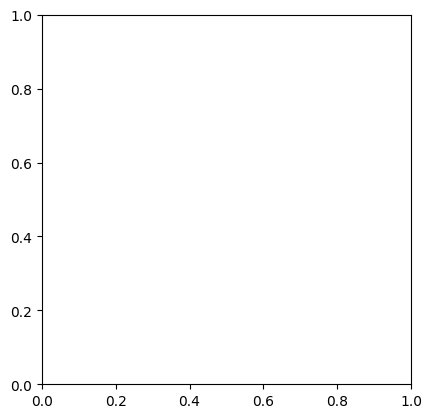

In [297]:
plt.imshow(np.mean(arrs['rchfngr']['i_stack'][56], axis=0))

In [299]:
arrs['rchfngr']['i_stack'][56]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(47, 57))

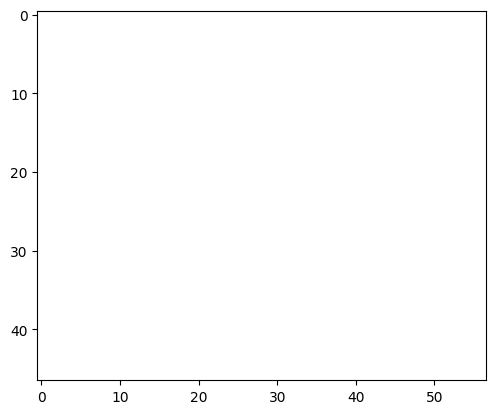

In [298]:
plt.imshow(arrs['rchfngr']['i_stack'][56])

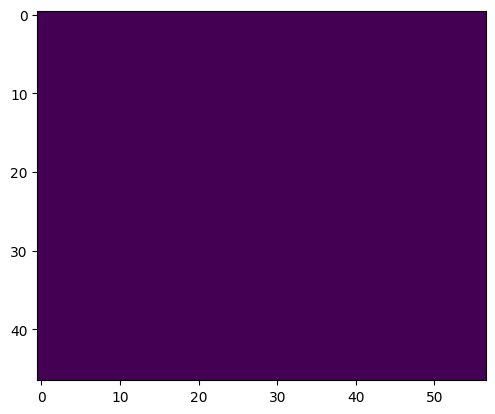

In [255]:
plt.imshow(arrs['npfklayer1cn']['mean'])

### Histogram compare plots

In [13]:
pt_oe

return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:1_kstp:1_time:1,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:10_time:11,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:11_time:12,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:12_time:13,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:13_time:14,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:14_time:15,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:15_time:16,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:16_time:17,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:17_time:18,oname:ts-heads_otype:lst_usecol:pk4-conf-diff_kper:2_kstp:18_time:19,...,oname:budget_otype:lst_usecol:stoss_kper:3,oname:budget_otype:lst_usecol:stoss_kper:4,oname:budget_otype:lst_usecol:sw_kper:1,oname:budget_otype:lst_usecol:sw_kper:2,oname:budget_otype:lst_usecol:sw_kper:3,oname:budget_otype:lst_usecol:sw_kper:4,oname:budget_otype:lst_usecol:total_kper:1,oname:budget_otype:lst_usecol:total_kper:2,oname:budget_otype:lst_usecol:total_kper:3,oname:budget_otype:lst_usecol:total_kper:4
real_name,,,,,,,,,,,,,,,,,,,,,
0,6.340968,5.931021,5.883607,5.837526,5.791213,5.744354,5.698255,5.651916,5.604632,5.557007,...,0,4292.3965,-85489.5500,-61039.9340,-54702.1900,-49813.1640,-0.445312,-0.031250,0.445312,-0.003906
1,5.643864,5.852721,5.806015,5.760580,5.714929,5.668749,5.623319,5.577677,5.531122,5.484228,...,0,381.8222,-97304.9700,-62848.6700,-108559.1000,-89538.0300,-0.273438,-0.640625,0.101562,-0.789062
2,6.359254,5.915854,5.868631,5.822030,5.775568,5.728878,5.682496,5.636117,5.589242,5.541979,...,0,32861.8100,-108333.5000,-112438.6400,-122059.9700,-105672.9600,-4.859375,0.000000,0.093750,-0.953125
3,6.280620,5.931021,5.883607,5.837527,5.791214,5.744354,5.698255,5.651917,5.604633,5.557008,...,0,1441.2949,-1305.1534,-1329.3807,-1527.8243,-1627.0242,0.003418,0.000000,0.000244,0.000000
4,6.587736,5.931067,5.883652,5.837567,5.791252,5.744391,5.698289,5.651949,5.604665,5.557039,...,0,7167.7360,-2423.2412,-5597.4556,-2055.2185,-7428.0560,-8.348633,-0.021484,4.498047,0.025391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,6.219496,5.958930,5.911564,5.865271,5.818788,5.771802,5.725401,5.678834,5.631474,5.583782,...,0,1378.5106,-4819.1377,-3158.3635,-3497.9988,-2902.3887,-7.173828,-6.330078,10.693359,-3.339844
196,6.837449,6.054458,6.003206,5.952885,5.903057,5.853431,5.804383,5.755665,5.706919,5.658216,...,0,19042.4160,-1179.6979,-15042.4890,-1743.9105,-19072.6130,4.152344,-0.511719,11.049805,-0.328125
197,6.228570,5.812428,5.769219,5.725832,5.682268,5.638515,5.594613,5.550562,5.506330,5.461914,...,0,17398.5300,-53029.8550,-35328.6700,-240288.1200,-173961.7000,-0.003906,0.000000,0.046875,0.000000


##### subset

In [12]:
# Decide which columns you want to load
desired_cols = [col for col in headers if (col.startswith('oname:confq')) & ('kper:2' in col) & ('kstp:30' in col)]

# data
pt_oe_confq = pd.read_csv(pt_oe_fn, usecols=desired_cols)

In [46]:
# get indexes where values in the columns are positive
pt_reals_list = set()
for col in desired_cols:
    positive_idxs = pt_oe_confq.index[pt_oe_confq[col] > 0].tolist()
    pt_reals_list.update(positive_idxs)
pt_reals_list

{68, 69, 76, 102, 103, 125, 172, 178, 188}

In [112]:
pt_reals_list = [102]

##### plot


Parameter groups to plot (25):
  - ghbaw-cond-cn
  - ghbaw-cond-gr
  - ghbaw-head-cn
  - ghbaw-head-hg
  - ghbconf-cond-cn
  - ghbconf-cond-gr
  - ghbconf-head-cn
  - ghbconf-head-hg
  - ghbpw-cond-cn
  - ghbpw-cond-gr
  - ghbpw-head-cn
  - ghbpw-head-hg
  - ghbspring-cond-cn
  - ghbspring-cond-gr
  - ghbspring-head-cn
  - ghbspring-head-hg
  - npfklayer1-cn
  - npfklayer1-gr
  - npfklayer1-pp
  - rcharecharge0-cn
  - rcharecharge0-gr
  - rcharecharge0-pp
  - stosslayer1-cn
  - stosslayer1-gr
  - stosslayer1-pp


C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\294482251.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\294482251.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\294482251.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\tfo46\AppData\Local\Temp\ipykernel_72712\294482251.py:34: FutureWarning: Series.__getitem__ tr


Figure saved to: ../models/local_run26/figures\output.parameter_group_histograms.png


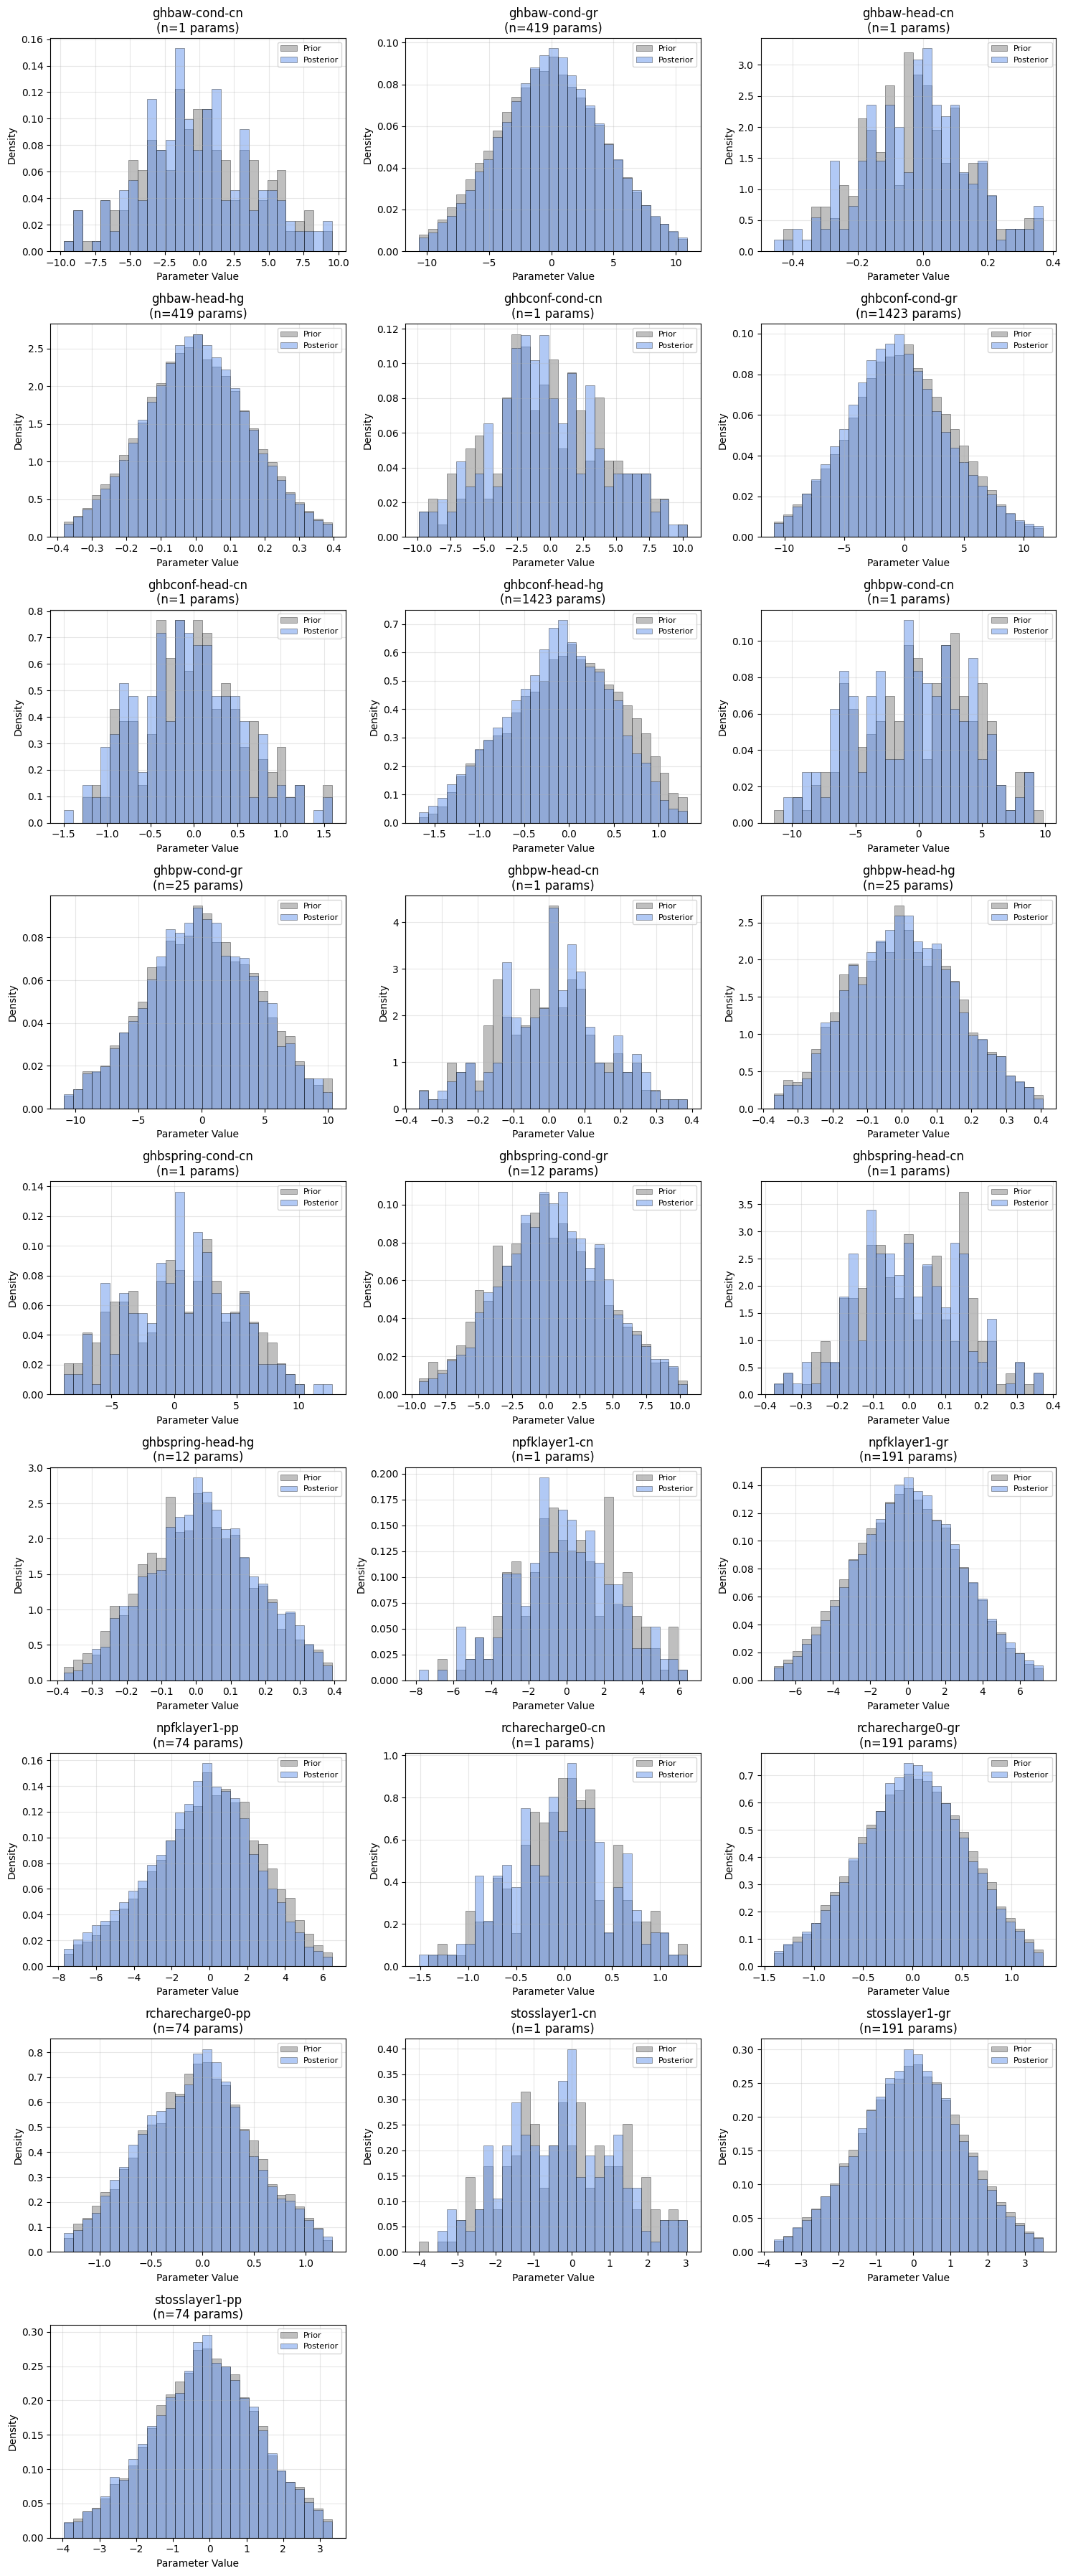


SUMMARY STATISTICS

ghbaw-cond-cn (1 parameters):
  Prior:     mean=959.0167, std=7363.3789
  Posterior: mean=5495.1897, std=70563.0302
  Std reduction: -858.3%

ghbaw-cond-gr (419 parameters):
  Prior:     mean=3124.5131, std=41264.2314
  Posterior: mean=5931.9362, std=64552.5035
  Std reduction: -56.4%

ghbaw-head-cn (1 parameters):
  Prior:     mean=-0.0256, std=0.1659
  Posterior: mean=-0.0155, std=0.1772
  Std reduction: -6.8%

ghbaw-head-hg (419 parameters):
  Prior:     mean=0.0009, std=0.1637
  Posterior: mean=0.0021, std=0.1621
  Std reduction: 1.0%

ghbconf-cond-cn (1 parameters):
  Prior:     mean=818.9535, std=6778.2556
  Posterior: mean=1230.2962, std=8646.5149
  Std reduction: -27.6%

ghbconf-cond-gr (1423 parameters):
  Prior:     mean=3437.3957, std=44519.0565
  Posterior: mean=9093.6787, std=82455.8403
  Std reduction: -85.2%

ghbconf-head-cn (1 parameters):
  Prior:     mean=0.0040, std=0.6288
  Posterior: mean=-0.0714, std=0.6423
  Std reduction: -2.1%

ghbconf-head

In [15]:
subset = False

# Get parameter groups (excluding those starting with 's_1_')
all_groups = par_data['pargp'].unique()
par_groups = [g for g in all_groups if not g.startswith('s_1_')]
print(f"\nParameter groups to plot ({len(par_groups)}):")
for g in sorted(par_groups):
    print(f"  - {g}")

# Filter pt_reals to only include valid realization indices
if subset:
    valid_pt_reals = [r for r in pt_reals_list if r < len(pt_pe)]
    if len(valid_pt_reals) < len(pt_reals_list):
        print(f"\nWarning: Only {len(valid_pt_reals)} of {len(pt_reals_list)} requested realizations exist")
        print(f"Valid realizations: {valid_pt_reals}")

    # Create subset of posterior for highlighted realizations
    pt_subset = pt_pe.iloc[valid_pt_reals]

# Plot histograms for each parameter group
n_groups = len(par_groups)
n_cols = 3
n_rows = int(np.ceil(n_groups / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_groups > 1 else [axes]

for idx, pargp in enumerate(sorted(par_groups)):
    ax = axes[idx]

    # Get parameters in this group
    pars_in_group = par_data[par_data['pargp'] == pargp].index.tolist()
    # get parameter transform
    transform = par_data.loc[pars_in_group]['partrans'][0]

    if len(pars_in_group) == 0:
        ax.text(0.5, 0.5, f'No parameters\nin {pargp}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(pargp)
        continue

    # Get values for all realizations and all parameters in this group
    prior_vals = pr_pe.loc[:, pars_in_group].values.flatten()
    posterior_vals = pt_pe.loc[:, pars_in_group].values.flatten()

    if subset:
        subset_vals = pt_subset.loc[:, pars_in_group].values.flatten()

    if transform == 'log':
        prior_vals = np.log(prior_vals)
        posterior_vals = np.log(posterior_vals)

        if subset:
            subset_vals = np.log(subset_vals)

    # Determine histogram bins based on combined data range
    all_vals = np.concatenate([prior_vals, posterior_vals])
    bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 30)

    # Plot histograms
    ax.hist(prior_vals, bins=bins, alpha=0.5, color='grey',
            label='Prior', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(posterior_vals, bins=bins, alpha=0.5, color='cornflowerblue',
            label='Posterior', density=True, edgecolor='black', linewidth=0.5)
    if subset:
        ax.hist(subset_vals, bins=bins, alpha=0.7, color='darkblue',
                label=f'Subset (n={len(valid_pt_reals)})', density=True,
                edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Density')
    ax.set_title(f'{pargp}\n(n={len(pars_in_group)} params)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Remove empty subplots
for idx in range(n_groups, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(os.path.join(output, 'output.parameter_group_histograms.png'),
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {os.path.join(output, 'output.parameter_group_histograms.png')}")
plt.show()

# Optional: Print summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
for pargp in sorted(par_groups):
    pars_in_group = par_data[par_data['pargp'] == pargp].index.tolist()
    if len(pars_in_group) == 0:
        continue

    prior_vals = pr_pe.loc[:, pars_in_group].values.flatten()
    posterior_vals = pt_pe.loc[:, pars_in_group].values.flatten()

    print(f"\n{pargp} ({len(pars_in_group)} parameters):")
    print(f"  Prior:     mean={np.mean(prior_vals):.4f}, std={np.std(prior_vals):.4f}")
    print(f"  Posterior: mean={np.mean(posterior_vals):.4f}, std={np.std(posterior_vals):.4f}")
    print(f"  Std reduction: {(1 - np.std(posterior_vals)/np.std(prior_vals))*100:.1f}%")
